# Primena konvolucionih neuronskih mreža i transfer learning pristupa u klasifikaciji nodula štitne žlezde

## 1. Uvoz potrebnih biblioteka

U ovom delu su uvezene sve biblioteke neophodne za rad sa podacima, obradu slika, definisanje i treniranje dubokih neuronskih mreža, kao i za evaluaciju performansi modela.

Korišćeni su PyTorch i torchvision za implementaciju modela i transformacija, PIL za učitavanje slika, pandas i NumPy za rad sa podacima, kao i biblioteke iz scikit-learn paketa za podelu skupa podataka i izračunavanje evaluacionih metrika.


In [ ]:
import os
import random
import xml.etree.ElementTree as ET
from PIL import Image
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.models as models
from torchvision import transforms
import timm

from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Podešavanje seed vrednosti i izbor uređaja

U ovom delu je definisana funkcija za postavljanje fiksne seed vrednosti kako bi rezultati eksperimenta bili reproduktivni i dosledni pri svakom pokretanju koda. Takođe je izvršena provera dostupnosti GPU uređaja, nakon čega je izabran odgovarajući uređaj za treniranje modela (GPU ukoliko je dostupan, u suprotnom CPU).

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 3. Provera dostupnosti GPU resursa

U ovoj sekciji korišćena je komanda `nvidia-smi` radi provere dostupnosti NVIDIA grafičke kartice, kao i uvida u njene tehničke karakteristike i trenutno zauzeće memorije. Ovaj korak je važan kako bi se potvrdilo da je GPU pravilno povezan i spreman za ubrzano treniranje modela.

In [ ]:
!nvidia-smi

Mon Mar 30 11:18:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 4. Povezivanje Google Drive skladišta

U ovom koraku izvršeno je povezivanje Google Colab okruženja sa Google Drive skladištem kako bi se omogućio pristup datasetu, anotacijama i sačuvanim rezultatima eksperimenata. Na ovaj način podaci i modeli mogu biti direktno učitavani i čuvani tokom rada u Colab okruženju.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 5. Definisanje prilagođene klase skupa podataka

U ovoj sekciji definisana je prilagođena klasa `ThyroidDataset`, nasleđena iz PyTorch `Dataset` klase, koja služi za učitavanje i pripremu podataka za treniranje modela.


Klasa automatski učitava slike i odgovarajuće XML anotacije, parsira informacije o klasi i koordinatama bounding box regiona, a zatim izdvaja oblast od interesa koja sadrži nodul štitne žlezde.

Dodatno je primenjena margina oko anotiranog regiona kako bi se obuhvatio i širi kontekst oko nodula, što može doprineti boljem učenju modela.

Nakon izdvajanja regiona, po potrebi se primenjuju transformacije nad slikom, a rezultat funkcije predstavlja pripremljenu sliku i njenu odgovarajuću klasu.

In [ ]:
class ThyroidDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, transform=None, margin=0.1):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.transform = transform
        self.margin = margin
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])

    def parse_xml(self, xml_path):
        tree = ET.parse(xml_path)
        root = tree.getroot()
        label = int(root.find("object").find("name").text)
        bbox = root.find("object").find("bndbox")

        coords = {k: int(bbox.find(k).text) for k in ['xmin','ymin','xmax','ymax']}
        w, h = coords['xmax'] - coords['xmin'], coords['ymax'] - coords['ymin']
        coords['xmin'] = max(0, coords['xmin'] - int(w*self.margin))
        coords['ymin'] = max(0, coords['ymin'] - int(h*self.margin))
        coords['xmax'] = coords['xmax'] + int(w*self.margin)
        coords['ymax'] = coords['ymax'] + int(h*self.margin)
        return label, coords['xmin'], coords['ymin'], coords['xmax'], coords['ymax']

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        xml_path = os.path.join(self.annotation_dir, img_name.replace('.jpg', '.xml'))

        image = Image.open(img_path).convert('RGB')
        label, xmin, ymin, xmax, ymax = self.parse_xml(xml_path)
        image = image.crop((xmin, ymin, xmax, ymax))

        if self.transform:
            image = self.transform(image)
        return image, label


## 6. Definisanje baznog CNN modela

U ovoj sekciji definisan je bazni konvolucioni neuronski model (`BaselineCNN`) koji služi kao referentna arhitektura za poređenje sa naprednijim transfer learning modelima.

 Model se sastoji od tri konvoluciona sloja sa rastućim brojem filtera, pri čemu se nakon svakog sloja primenjuju ReLU aktivaciona funkcija i max-pooling operacija radi izdvajanja relevantnih karakteristika i smanjenja dimenzionalnosti ulaznih podataka.

 Nakon ekstrakcije karakteristika, dobijeni tenzor se transformiše u vektor i prosleđuje kroz potpuno povezane (fully connected) slojeve, pri čemu završni sloj vrši binarnu klasifikaciju u dve klase.

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(128*16*16, 256)
        self.fc2 = nn.Linear(256,2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


## 7. Definisanje DenseNet121 modela sa transfer učenjem

U ovom delu implementiran je model `DenseNet121Transfer`, zasnovan na unapred treniranoj DenseNet121 arhitekturi.

Korišćenjem transfer učenja preuzeta je mreža prethodno obučena na ImageNet skupu podataka, dok je originalni klasifikacioni sloj zamenjen prilagođenim klasifikatorom za binarni problem klasifikacije.

Novi klasifikacioni deo uključuje potpuno povezani sloj, ReLU aktivacionu funkciju, **dropout sloj kao tehniku regularizacije**, i završni izlazni sloj sa dve klase. Konkretno, korišćen je `Dropout(0.5)`, što znači da se tokom treniranja nasumično isključuje 50% neurona u tom sloju. Na taj način se smanjuje prevelika zavisnost modela od pojedinačnih neurona i doprinosi se boljoj generalizaciji modela na neviđenim podacima.

Uvođenje dropout regularizacije je posebno značajno kod medicinskih skupova podataka, gde postoji povećan rizik od overfitting-a zbog ograničenog broja uzoraka.

In [ ]:
class DenseNet121Transfer(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        self.backbone = models.densenet121(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes)
        )
    def forward(self,x): return self.backbone(x)


## 8. Definisanje ResNet50 modela sa transfer učenjem

U ovoj sekciji definisan je model `ResNet50Transfer`, koji koristi unapred treniranu ResNet50 arhitekturu u okviru transfer learning pristupa.

Osnovna ideja je zadržavanje dubokog ekstraktora karakteristika treniranog na velikom skupu podataka, dok se završni potpuno povezani sloj zamenjuje novim slojem prilagođenim binarnoj klasifikaciji.

Ovaj model koristi rezidualne veze, koje omogućavaju stabilnije treniranje dubokih mreža i efikasnije učenje složenih obrazaca u medicinskim slikama.

In [ ]:
class ResNet50Transfer(nn.Module):
    def __init__(self,num_classes=2,pretrained=True):
        super().__init__()
        self.backbone = models.resnet50(pretrained=pretrained)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features,num_classes)
    def forward(self,x): return self.backbone(x)


## 9. Definisanje EfficientNet-B0 modela sa transfer učenjem

U ovom delu implementiran je model `EfficientNetB0Transfer`, zasnovan na unapred treniranoj EfficientNet-B0 arhitekturi.

EfficientNet predstavlja savremeni pristup dizajnu konvolucionih mreža, pri čemu se dubina, širina i rezolucija mreže balansirano skaliraju radi postizanja visokih performansi uz relativno malu računarsku složenost.

U okviru transfer učenja, originalni klasifikacioni sloj zamenjen je novim linearnim slojem prilagođenim problemu binarne klasifikacije, čime se model specijalizuje za analizu ultrazvučnih slika nodula štitne žlezde.

In [ ]:
class EfficientNetB0Transfer(nn.Module):
    def __init__(self,num_classes=2,pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b0', pretrained=pretrained)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Linear(in_features,num_classes)
    def forward(self,x): return self.backbone(x)


## 10. Definisanje InceptionV3 modela sa transfer učenjem

U ovoj sekciji definišemo **`InceptionV3Transfer`** model, koji koristi unapred treniranu **InceptionV3** arhitekturu za binarnu klasifikaciju.

Glavne karakteristike modela:  
- **Transfer učenje**: Model koristi težine prethodno treniranog InceptionV3
- **Feature extraction opcija**: Postoji mogućnost da se svi slojevi osim finalnog klasifikatora zamrznu (`feature_extract=True`), čime se treniraju samo poslednji slojevi, dok ostali zadržavaju naučene reprezentacije.  
- **Dropout regularizacija**: Finalni linearni slojevi (glavni i pomoćni) imaju dropout, što pomaže u sprečavanju overfittinga.  
- **Glavni i pomoćni izlazi**: Tokom treninga model koristi **glavni izlaz** i **pomoćni (auxiliary) klasifikator**, što poboljšava protok gradijenata kroz mrežu i doprinosi stabilnijem učenju.  
- **Evaluacija**: U fazi evaluacije (bez treniranja) model vraća samo glavni izlaz, što je standardno za InceptionV3 arhitekturu.

Finalni linearni slojevi su prilagođeni broju ciljnih klasa (`num_classes`), a parametri ovih slojeva su uvek trainable, čak i kada je feature extraction aktivan.

In [ ]:
from torchvision.models import Inception_V3_Weights

class InceptionV3Transfer(nn.Module):
    def __init__(self, num_classes=2, feature_extract=True, dropout=0.4):
        super().__init__()

        weights = Inception_V3_Weights.DEFAULT  #ucitavanje pretrained modela
        self.backbone = models.inception_v3(weights=weights, aux_logits=True)

        # zamrzavanje svih slojeva ako radimo feature extraction
        if feature_extract:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # final classifier
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

        # Aux classifier (samo tokom treninga)
        if self.backbone.AuxLogits is not None:
            in_features_aux = self.backbone.AuxLogits.fc.in_features
            self.backbone.AuxLogits.fc = nn.Sequential(
                nn.Dropout(p=dropout),
                nn.Linear(in_features_aux, num_classes)
            )

        # zamena fc slojeve => oni moraju da budu trainable
        for param in self.backbone.fc.parameters():
            param.requires_grad = True

        if self.backbone.AuxLogits is not None:
            for param in self.backbone.AuxLogits.fc.parameters():
                param.requires_grad = True

    def forward(self, x):
        if self.training:
            outputs = self.backbone(x)

            # InceptionOutputs(main_logits, aux_logits)
            if isinstance(outputs, tuple):
                main_logits, aux_logits = outputs
            else:
                main_logits = outputs.logits
                aux_logits = outputs.aux_logits

            return main_logits, aux_logits
        else:
            outputs = self.backbone(x)

            # eval => vraca samo glavni output
            if isinstance(outputs, tuple):
                main_logits = outputs[0]
            elif hasattr(outputs, "logits"):
                main_logits = outputs.logits
            else:
                main_logits = outputs

            return main_logits

In [ ]:
class VGG16Transfer(nn.Module):
    def __init__(self,num_classes=2,pretrained=True):
        super().__init__()
        self.backbone = models.vgg16(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = self.backbone.classifier[6].in_features
        self.backbone.classifier[6] = nn.Sequential(
            nn.Linear(in_features,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes)
        )
    def forward(self,x): return self.backbone(x)

## 13. Definisanje transformacija i augmentacije podataka

U ovoj sekciji definisane su transformacije koje se primenjuju nad slikama tokom treniranja i validacije modela.

Cilj transformacija je standardizacija ulaznih podataka, povećanje robusnosti modela i smanjenje rizika od preprilagođavanja (overfitting-a). Posebno je za trening skup primenjena augmentacija podataka kako bi model bio izložen većoj varijabilnosti ulaznih slika.

### Transformacije primenjene nad trening skupom

- **Resize (`input_size + 32`)**  
  Slika se najpre uvećava na nešto veću dimenziju od ciljne ulazne veličine.  
  **Razlog:** omogućava kasnije nasumično kropovanje različitih delova slike, čime se povećava raznovrsnost uzoraka.

- **RandomResizedCrop (`input_size`, `scale=(0.8, 1.0)`)**  
  Nasumično se bira region slike koji zauzima između 80% i 100% originalne površine, a zatim se taj region skalira na ciljnu veličinu.  
  **Razlog:** model postaje otporniji na manje promene položaja, veličine i okvira nodula, što poboljšava generalizaciju.

- **RandomHorizontalFlip()**  
  Slika se nasumično horizontalno obrće.  
  **Razlog:** povećava varijabilnost podataka i smanjuje zavisnost modela od orijentacije slike.

- **RandomVerticalFlip()**  
  Slika se nasumično vertikalno obrće.  
  **Razlog:** dodatno proširuje skup mogućih varijacija ulaza i pomaže modelu da uči robusnije karakteristike.

- **RandomRotation(20)**  
  Slika se nasumično rotira do ±20 stepeni.  
  **Razlog:** simulira male promene ugla snimanja tokom ultrazvučnog pregleda i čini model otpornijim na rotacione varijacije.

- **RandomApply([GaussianBlur], p=0.3)**  
  Sa verovatnoćom od 30% primenjuje se blago zamućenje slike.  
  **Razlog:** simulira različit kvalitet snimka i prisustvo šuma, čime model postaje otporniji na manje degradacije slike.

- **ColorJitter (brightness=0.08, contrast=0.08)**  
  Nasumično se menjaju osvetljenje i kontrast slike u blagom opsegu.  
  **Razlog:** simulira razlike u intenzitetu i kontrastu ultrazvučnih snimaka nastale usled različitih uslova akvizicije.

- **ToTensor()**  
  Slika se konvertuje u PyTorch tenzor.  
  **Razlog:** omogućava dalju obradu slike u okviru neuronske mreže.

- **Normalize(mean, std)**  
  Piksel vrednosti se normalizuju korišćenjem standardnih ImageNet srednjih vrednosti i standardnih devijacija.  
  **Razlog:** obezbeđuje konzistentan opseg ulaznih podataka i usklađuje ih sa očekivanim ulazom unapred treniranih modela korišćenih u transfer učenju.

### Transformacije primenjene nad validacionim skupom

Za validacioni skup korišćene su samo determinističke transformacije:

- **Resize (`input_size`)** – standardizacija dimenzija ulazne slike
- **ToTensor()** – konverzija slike u tenzor
- **Normalize(mean, std)** – normalizacija u skladu sa ImageNet standardom

**Razlog:** nad validacionim skupom se ne primenjuje augmentacija, kako bi evaluacija modela bila konzistentna i objektivna, bez uvođenja dodatne nasumičnosti.

In [ ]:
def get_transforms(input_size=224):
    train_transform = transforms.Compose([
        transforms.Resize((input_size+32,input_size+32)),
        transforms.RandomResizedCrop(input_size, scale=(0.8,1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.3),
        transforms.ColorJitter(brightness=0.08,contrast=0.08),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    val_transform = transforms.Compose([
        transforms.Resize((input_size,input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    return train_transform,val_transform


## 14. Kreiranje modela na osnovu izabrane arhitekture

U ovoj sekciji definisana je funkcija `create_model`, koja omogućava dinamičko kreiranje modela na osnovu naziva odabrane arhitekture. Funkcija predstavlja centralizovan mehanizam za instanciranje različitih modela korišćenih u eksperimentima, uključujući bazni CNN model i više transfer learning arhitektura kao što su DenseNet121, ResNet50, EfficientNet-B0, InceptionV3, VGG16 i ConvNeXt Tiny.

Ovakav pristup pojednostavljuje organizaciju i omogućava lakše poređenje različitih modela i olakšava automatizovano pokretanje više eksperimenata u okviru AutoML ili grid search procesa. U slučaju unosa nepoznatog naziva modela, funkcija generiše odgovarajuću grešku, čime se sprečava nenamerno korišćenje nevalidne arhitekture.

In [ ]:
def create_model(model_name):
    if model_name == "baseline":
        return BaselineCNN()
    elif model_name == "densenet":
        return DenseNet121Transfer()
    elif model_name == "resnet":
        return ResNet50Transfer()
    elif model_name == "efficientnet":
        return EfficientNetB0Transfer()
    elif model_name == "inception":
        return InceptionV3Transfer()
    elif model_name == "vgg":
        return VGG16Transfer()
    elif model_name == "convnext":
        return ConvNeXtTinyTransfer()
    else:
        raise ValueError("Nepoznat model!")

## 15. Definisanje funkcije za treniranje i validaciju modela

U ovoj sekciji definišemo funkciju **`train_model`**, koja realizuje kompletan proces **treniranja i validacije** izabranog modela kroz zadati broj epoha. Funkcija omogućava:

- optimizaciju parametara modela  
- praćenje performansi tokom učenja  
- čuvanje najboljeg modela na osnovu evaluacionih metrika  

### Ključne funkcionalnosti funkcije

- **Postavljanje modela na odgovarajući uređaj**  
  Model se premešta na prethodno definisani uređaj (`GPU` ili `CPU`) radi efikasnog izvođenja treninga.

- **Definisanje funkcije gubitka**  
  Kao funkcija gubitka koristi se **`CrossEntropyLoss`**, standardan izbor za višeklasne i binarne klasifikacione probleme sa logits izlazima.

- **Izbor optimizacionog algoritma**  
  Funkcija podržava dva optimizatora:  
  - **Adam** – adaptivni optimizator koji često omogućava brže i stabilnije konvergiranje  
  - **SGD sa momentum-om** – klasičan optimizator koji može dati bolju generalizaciju uz pravilno podešene hiperparametre  

  Uključen je i parametar **weight decay**, oblik L2 regularizacije koji pomaže u smanjenju overfitting-a.  

- **Trening samo za trainable parametre**  
  Kada se koristi **transfer learning**, funkcija ažurira samo parametre slojeva koji su trainable, dok ostali slojevi ostaju zamrznuti.

- **Praćenje istorije performansi**  
  Tokom treniranja čuvaju se vrednosti:  
  - trening gubitak (`train_loss`)  
  - validacioni gubitak (`val_loss`)  
  - preciznost (`precision`)  
  - odziv (`recall`)  
  - F1 mera (`F1-score`)  

  Ove vrednosti omogućavaju analizu procesa učenja i poređenje različitih modela i hiperparametara.

### Faza treniranja

U svakoj epohi model se postavlja u režim treniranja (`model.train()`), nakon čega se za svaki batch podataka izvršavaju sledeći koraci:

- učitavanje slika i labela na odgovarajući uređaj  
- poništavanje prethodno izračunatih gradijenata (`optimizer.zero_grad()`)  
- propagacija unapred kroz mrežu (`forward pass`)  
  - za Inception modele koristi se **glavni i pomoćni (auxiliary) izlaz**  
  - pomoćni izlaz doprinosi boljem protoku gradijenata i stabilnijem učenju  
- izračunavanje funkcije gubitka  
  - gubitak se kombinuje sa pomoćnim izlazom pomoću pondera (npr. `0.4 * loss_aux`)  
- propagacija unazad (`backpropagation`)  
- ažuriranje težina modela pomoću optimizatora  

Na kraju epohe računa se prosečan trening gubitak nad celim trening skupom.

### Faza validacije

Nakon završetka trening faze u okviru svake epohe, model se prebacuje u **evaluacioni režim** (`model.eval()`), pri čemu se deaktiviraju mehanizmi specifični za trening (dropout, batch norm). Tokom validacije:

- ne računaju se gradijenti (`torch.no_grad()`)  
- izračunava se validacioni gubitak  
- generišu se predikcije modela  
- prikupljaju se stvarne i predviđene klase radi izračunavanja metrika  

Za evaluaciju se koriste sledeće metrike:

- **Precision** – procenat tačno klasifikovanih pozitivnih uzoraka među svim pozitivnim predikcijama  
- **Recall** – procenat tačno prepoznatih pozitivnih uzoraka među stvarno pozitivnim uzorcima  
- **F1-score** – harmonijska sredina precision i recall metrike, posebno korisna kod neuravnoteženih skupova podataka  

Sve metrike se računaju korišćenjem **weighted proseka**, čime se uzima u obzir raspodela klasa u skupu podataka.

### Čuvanje najboljeg modela

Tokom treniranja prati se najbolja ostvarena vrednost **F1 mere** na validacionom skupu. Ukoliko trenutna epoha ostvari bolji F1 rezultat od prethodnog najboljeg:

- model se čuva na disku u direktorijumu `results`  
- naziv fajla uključuje ime modela i oznaku da je najbolji (`*_best.pth`)  

### Povratna vrednost funkcije

Funkcija vraća strukturirani rečnik sa kompletnom istorijom treniranja, uključujući:

- gubitke po epohama  
- evaluacione metrike po epohama  
- najbolji validacioni gubitak  
- najbolju F1 meru  
- putanju do sačuvanog najboljeg modela  



In [ ]:
def train_model(model, train_loader, val_loader, device, model_name,
                epochs=10, lr=1e-3, optimizer_name="adam", weight_decay=1e-4):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # samo trainable parametri (bitno za transfer learning)
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    if optimizer_name == "adam":
        optimizer = optim.Adam(trainable_params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        optimizer = optim.SGD(trainable_params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError("Nepoznat optimizer!")

    train_losses = []
    val_losses = []
    precisions = []
    recalls = []
    f1_scores = []

    best_val_loss = float("inf")
    best_f1 = 0.0
    best_model_path = None

    os.makedirs("results", exist_ok=True)

    is_inception = "inception" in model_name.lower()

    for epoch in range(epochs):
        # ==========================
        # TRAIN
        # ==========================
        model.train()
        running_train_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            if is_inception:
                outputs = model(images)

                # main_logits, aux_logits u train modu
                if isinstance(outputs, tuple):
                    main_logits, aux_logits = outputs
                else:
                    # fallback ako se desi drugaciji format
                    main_logits = outputs
                    aux_logits = None

                loss_main = criterion(main_logits, labels)

                if aux_logits is not None:
                    loss_aux = criterion(aux_logits, labels)
                    loss = loss_main + 0.4 * loss_aux
                else:
                    loss = loss_main

                outputs_for_preds = main_logits

            else:
                outputs = model(images)

                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)
                outputs_for_preds = outputs

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # ==========================
        # VALIDATION
        # ==========================
        model.eval()
        running_val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)

                # u eval modu Inception treba da vrati samo main logits
                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f} | "
            f"F1: {f1:.4f}"
        )

        # cuvaj najbolji po F1
        if f1 > best_f1:
            best_f1 = f1
            best_val_loss = epoch_val_loss
            best_model_path = f"results/{model_name}_best.pth"
            torch.save(model.state_dict(), best_model_path)
            print(f"   ✅ Save: {best_model_path}")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "precisions": precisions,
        "recalls": recalls,
        "f1_scores": f1_scores,
        "best_val_loss": best_val_loss,
        "best_f1": best_f1,
        "best_model_path": best_model_path
    }

## 16. Implementacija AutoML / Grid Search procedure za optimizaciju hiperparametara

U ovoj sekciji definisana je funkcija `run_automl`, koja realizuje automatizovano ispitivanje različitih kombinacija hiperparametara korišćenjem pristupa zasnovanog na **grid search** pretrazi. Cilj ove procedure je identifikacija najbolje konfiguracije modela u smislu performansi na validacionom skupu, pri čemu se porede različite kombinacije optimizatora, brzine učenja i veličine batch-a.

### Definisanje prostora pretrage hiperparametara

Na početku funkcije definiše se prostor pretrage (`search_space`) koji obuhvata sledeće hiperparametre:

- **Optimizer**: `Adam`, `SGD`
- **Learning rate**:
  - za većinu modela: `1e-3`, `1e-4`
  - za `ConvNeXt Tiny`: `1e-4`, `5e-5`
- **Batch size**: `16`, `32`

Za model **ConvNeXt Tiny** korišćen je drugačiji opseg learning rate vrednosti, jer savremenije i dublje arhitekture često zahtevaju niže vrednosti brzine učenja kako bi treniranje bilo stabilnije i kako bi se izbeglo preveliko oscilovanje tokom optimizacije.

### Inicijalizacija struktura za čuvanje rezultata

Tokom izvršavanja funkcije kreiraju se promenljive i strukture za:

- čuvanje rezultata svih eksperimenata
- praćenje najbolje ostvarene F1 mere
- čuvanje najbolje konfiguracije hiperparametara
- čuvanje putanje do najboljeg sačuvanog modela

Takođe se automatski kreiraju direktorijumi:

- `results/` – za čuvanje modela i rezultata
- `results/plots/` – za čuvanje generisanih grafikona

### Prilagođavanje ulazne dimenzije slici modela

Ulazna dimenzija slike (`input_size`) određuje se u skladu sa zahtevima konkretne arhitekture:

- **InceptionV3** → `299 × 299`
- **BaselineCNN** → `128 × 128`
- **Ostali modeli** → `224 × 224`

Na osnovu izabrane ulazne veličine generišu se odgovarajuće transformacije za trening i validaciju.

### Podela skupa podataka

Kompletan skup podataka se najpre učitava kroz klasu `ThyroidDataset`, nakon čega se izdvajaju labele radi stratifikovane podele. Podela se vrši u dve faze:

1. **StratifiedShuffleSplit**  
   Skup se deli na:
   - **70% trening skup**
   - **30% privremeni skup**

2. **train_test_split** nad privremenim skupom  
   Privremeni skup se dalje deli na:
   - **15% validacioni skup**
   - **15% test skup**

Primenom **stratifikacije** obezbeđuje se očuvanje odnosa klasa u svim podskupovima, što je posebno značajno kod medicinskih skupova podataka, gde često postoji neuravnoteženost između klasa.

### Kreiranje DataLoader objekata

Za svaku kombinaciju hiperparametara kreiraju se odgovarajući `DataLoader` objekti:

- `train_loader` – sa nasumičnim mešanjem uzoraka (`shuffle=True`)
- `val_loader` – bez mešanja (`shuffle=False`)
- `test_loader` – bez mešanja (`shuffle=False`)

Veličina batch-a se dinamički menja u skladu sa trenutnom konfiguracijom iz prostora pretrage.

### Pokretanje eksperimenata nad svim kombinacijama hiperparametara

Funkcija zatim prolazi kroz sve kombinacije definisanih hiperparametara:

- optimizer
- learning rate
- batch size

Za svaku kombinaciju:

- postavlja se seed radi reproduktivnosti rezultata
- kreira se odgovarajući model preko funkcije `create_model`
- generiše se jedinstveni naziv eksperimenta
- pokreće se treniranje i validacija pozivom funkcije `train_model`

Na ovaj način se za svaku konfiguraciju sistematski meri ponašanje modela i prikupljaju relevantni rezultati.

### Vizualizacija toka treniranja

Nakon svakog eksperimenta automatski se generišu i čuvaju dva grafikona:

#### 1. Train Loss vs Validation Loss
Prikazuje promenu funkcije gubitka kroz epohe na trening i validacionom skupu.

#### 2. Precision / Recall / F1-score kroz epohe
Prikazuje promenu ključnih evaluacionih metrika tokom validacije.

Oba grafikona se čuvaju u direktorijumu `results/plots`.

### Čuvanje zbirnih rezultata eksperimenata

Za svaku kombinaciju hiperparametara formira se zapis koji sadrži:

- korišćeni optimizator
- learning rate
- batch size
- najbolji validacioni gubitak
- najbolju F1 meru
- putanju do sačuvanog modela

Svi rezultati se zatim smeštaju u listu i na kraju konvertuju u `pandas DataFrame`, koji se sortira opadajuće prema najboljoj F1 meri.

### Izbor najbolje konfiguracije

Tokom izvršavanja funkcije kontinuirano se prati najbolja ostvarena vrednost **F1 mere**. Ukoliko trenutna konfiguracija nadmaši prethodnu najbolju, ona se beleži kao nova optimalna konfiguracija, zajedno sa putanjom do najboljeg modela.

**Razlog izbora F1 mere kao glavnog kriterijuma optimizacije:**  
Kod medicinskih klasifikacionih zadataka, posebno u slučaju moguće neuravnoteženosti klasa, F1 mera pruža uravnoteženiju procenu performansi od same tačnosti, jer istovremeno uzima u obzir i preciznost i odziv modela.

### Čuvanje konačnih rezultata

Na kraju procedure svi rezultati eksperimenata se:

- prikazuju u tabelarnom obliku
- čuvaju u CSV fajlu: `results/automl_results.csv`

Na taj način se omogućava:

- lakše poređenje konfiguracija
- dodatna analiza rezultata van notebook okruženja
- jednostavno uključivanje rezultata u izveštaj ili master rad

### Povratna vrednost funkcije

Funkcija na kraju vraća tri objekta:

- **`best_config`** – najbolju kombinaciju hiperparametara
- **`best_model_path`** – putanju do najboljeg sačuvanog modela
- **`results_df`** – tabelarni pregled svih testiranih konfiguracija

Ovakav dizajn omogućava jednostavno dalje korišćenje najboljeg modela za testiranje, evaluaciju i interpretaciju rezultata.

In [ ]:
def run_automl(model_name, image_dir, annotation_dir, device, epochs=8, seed=42):
    print("\n===== POKRETANJE AutoML / Grid Search =====\n")

    # search space
    if model_name == "convnext":
        search_space = {
            "optimizer": ["adam", "sgd"],
            "lr": [1e-4, 5e-5],
            "batch_size": [16, 32]
        }
    else:
        search_space = {
            "optimizer": ["adam", "sgd"],
            "lr": [1e-3, 1e-4],
            "batch_size": [16, 32]
        }

    results = []
    best_f1 = -1
    best_config = None
    best_model_path = None

    os.makedirs("results", exist_ok=True)
    os.makedirs("results/plots", exist_ok=True)

    # input size po modelu
    if model_name == "inception":
        input_size = 299
    elif model_name == "baseline":
        input_size = 128
    else:
        input_size = 224

    train_transform, val_transform = get_transforms(input_size=input_size)

    # dataset za train (sa train augmentacijama)
    full_dataset = ThyroidDataset(image_dir, annotation_dir, transform=train_transform)
    labels = [full_dataset[i][1] for i in range(len(full_dataset))]

    # stratified split: 70% train, 15% val, 15% test
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=seed)
    train_idx, temp_idx = next(sss.split(np.zeros(len(labels)), labels))

    temp_labels = [labels[i] for i in temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.5,
        stratify=temp_labels,
        random_state=seed
    )

    # odvojeni datasets (bitno: train koristi augmentacije, val/test ne)
    train_dataset = Subset(
        ThyroidDataset(image_dir, annotation_dir, transform=train_transform),
        train_idx
    )
    val_dataset = Subset(
        ThyroidDataset(image_dir, annotation_dir, transform=val_transform),
        val_idx
    )
    test_dataset = Subset(
        ThyroidDataset(image_dir, annotation_dir, transform=val_transform),
        test_idx
    )

    exp_num = 1

    for optimizer_name in search_space["optimizer"]:
        for lr in search_space["lr"]:
            for batch_size in search_space["batch_size"]:

                print(f"\nEksperiment {exp_num}")
                print(f"Optimizer = {optimizer_name}, LR = {lr}, Batch Size = {batch_size}")

                set_seed(seed)

                train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
                val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
                test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

                # model
                model = create_model(model_name)
                exp_model_name = f"{model_name}_{optimizer_name}_lr{lr}_bs{batch_size}"

                # train
                history = train_model(
                    model=model,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    device=device,
                    model_name=exp_model_name,
                    epochs=epochs,
                    lr=lr,
                    optimizer_name=optimizer_name,
                    weight_decay=1e-4
                )

                # ==========================
                # GRAFIKON 1: Train vs Validation Loss
                # ==========================
                epoch_range = range(1, len(history["train_losses"]) + 1)

                plt.figure(figsize=(8, 5))
                plt.plot(epoch_range, history["train_losses"], marker='o', label='Train Loss')
                plt.plot(epoch_range, history["val_losses"], marker='s', label='Validation Loss')
                plt.xlabel("Epoch")
                plt.ylabel("Loss")
                plt.title(
                    f"{model_name.upper()} | Opt={optimizer_name}, LR={lr}, BS={batch_size}\n"
                    f"Train vs Validation Loss"
                )
                plt.legend()
                plt.grid(True)
                plt.tight_layout()
                plt.savefig(f"results/plots/{exp_model_name}_loss.png")
                plt.show()

                # ==========================
                # GRAFIKON 2: Precision / Recall / F1-score
                # ==========================
                plt.figure(figsize=(8, 5))
                plt.plot(epoch_range, history["precisions"], marker='o', label='Precision')
                plt.plot(epoch_range, history["recalls"], marker='s', label='Recall')
                plt.plot(epoch_range, history["f1_scores"], marker='^', label='F1-score')
                plt.xlabel("Epoch")
                plt.ylabel("Score")
                plt.title(
                    f"{model_name.upper()} | Opt={optimizer_name}, LR={lr}, BS={batch_size}\n"
                    f"Precision / Recall / F1-score"
                )
                plt.legend()
                plt.grid(True)
                plt.tight_layout()
                plt.savefig(f"results/plots/{exp_model_name}_metrics.png")
                plt.show()

                # rezultat eksperimenta
                result = {
                    "optimizer": optimizer_name,
                    "lr": lr,
                    "batch_size": batch_size,
                    "best_val_loss": history["best_val_loss"],
                    "best_f1": history["best_f1"],
                    "model_path": history["best_model_path"]
                }

                results.append(result)

                if history["best_f1"] > best_f1:
                    best_f1 = history["best_f1"]
                    best_config = result
                    best_model_path = history["best_model_path"]

                exp_num += 1

    results_df = pd.DataFrame(results).sort_values(by="best_f1", ascending=False)

    print("\n===== AutoML REZULTATI =====")
    print(results_df)

    print("\nNAJBOLJA KONFIGURACIJA:")
    print(best_config)

    results_df.to_csv("results/automl_results.csv", index=False)

    print("\n📁 Grafikoni su sačuvani u folderu: results/plots")

    return best_config, best_model_path, results_df


## 17. Kopiranje skupa podataka iz Google Drive u lokalno Colab okruženje

U ovoj sekciji korišćena je komandna linija za kopiranje kompletnog direktorijuma sa skupom podataka iz Google Drive skladišta u lokalni radni direktorijum Colab okruženja (`/content/`).

Ovaj korak se primenjuje kako bi se ubrzalo učitavanje podataka tokom treniranja modela, s obzirom na to da je pristup fajlovima iz lokalnog Colab okruženja značajno brži u odnosu na direktan rad sa fajlovima sa Google Drive-a.

In [ ]:
!cp -r "/content/drive/MyDrive/data/TN5000_forReview" /content/

## 18. ConvNeXt Tiny Transfer Learning

Ova sekcija definiše PyTorch model koji koristi **ConvNeXt Tiny** arhitekturu kao backbone.  
Ključne tačke:
- Učitava **pretrained težine sa ImageNet** skupa (`pretrained=True`) radi bolje inicijalizacije modela.
- Originalni klasifikacioni sloj (`classifier[2]`) se zamenjuje novim slojem prilagođenim za **2 klase**:
  - Linearni sloj → ReLU → Dropout(0.4) → Linearni sloj (output = num_classes)
- Ovaj pristup omogućava **transfer learning**, gde model uči specifične karakteristike novog skupa podataka, koristeći prethodno naučene reprezentacije sa ImageNet-a.

In [ ]:
class ConvNeXtTinyTransfer(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        self.backbone = models.convnext_tiny(
            weights='IMAGENET1K_V1' if pretrained else None
        )

        in_features = self.backbone.classifier[2].in_features
        self.backbone.classifier[2] = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

## 19. AutoML Eksperiment sa odabranim modelom

Ovaj deo koda koristi definisanu funkciju `run_automl` za **automatsko pretraživanje hiperparametara** i treniranje odabranog modela.

- **Odabrani model:** `convnext` (ostale opcije: baseline, densenet, resnet, efficientnet, inception, vgg)
- **Parametri:**
  - epochs = 10
  - seed = 42 (za reproduktivnost)
  - putanje do dataset-a: `image_dir` i `annotation_dir` (JPEG slike i XML anotacije)
- Funkcija `run_automl`:
  - Kreira train/validation/test split uz **StratifiedShuffleSplit**.
  - Prolazi kroz sve kombinacije u definisanom **search space**: optimizer (adam/sgd), learning rate, batch size.
  - Treniranje se prati sa metrikama: **train/val loss, precision, recall, F1-score**.
  - Čuva najbolji model po F1-score u folder `results`.
  - Generiše i čuva grafike performansi po eksperimentu.

- Na kraju:
  - Ispisuje se **najbolja konfiguracija**.
  - Prikazuje se **putanja do najboljeg modela** (`best_model_path`) za kasnije korišćenje ili evaluaciju.


===== POKRETANJE AutoML / Grid Search =====


Eksperiment 1
Optimizer = adam, LR = 0.0001, Batch Size = 16
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 187MB/s] 


Epoch 1/10 | Train Loss: 0.4333 | Val Loss: 0.4231 | Precision: 0.8510 | Recall: 0.8493 | F1: 0.8383
   ✅ Save: results/convnext_adam_lr0.0001_bs16_best.pth
Epoch 2/10 | Train Loss: 0.3517 | Val Loss: 0.3230 | Precision: 0.8664 | Recall: 0.8627 | F1: 0.8529
   ✅ Save: results/convnext_adam_lr0.0001_bs16_best.pth
Epoch 3/10 | Train Loss: 0.3048 | Val Loss: 0.3162 | Precision: 0.8736 | Recall: 0.8720 | F1: 0.8727
   ✅ Save: results/convnext_adam_lr0.0001_bs16_best.pth
Epoch 4/10 | Train Loss: 0.3020 | Val Loss: 0.3065 | Precision: 0.8879 | Recall: 0.8880 | F1: 0.8836
   ✅ Save: results/convnext_adam_lr0.0001_bs16_best.pth
Epoch 5/10 | Train Loss: 0.3054 | Val Loss: 0.4646 | Precision: 0.8564 | Recall: 0.8427 | F1: 0.8249
Epoch 6/10 | Train Loss: 0.2922 | Val Loss: 0.3003 | Precision: 0.8802 | Recall: 0.8813 | F1: 0.8770
Epoch 7/10 | Train Loss: 0.2871 | Val Loss: 0.3679 | Precision: 0.8559 | Recall: 0.8480 | F1: 0.8336
Epoch 8/10 | Train Loss: 0.2805 | Val Loss: 0.3174 | Precision: 0.871

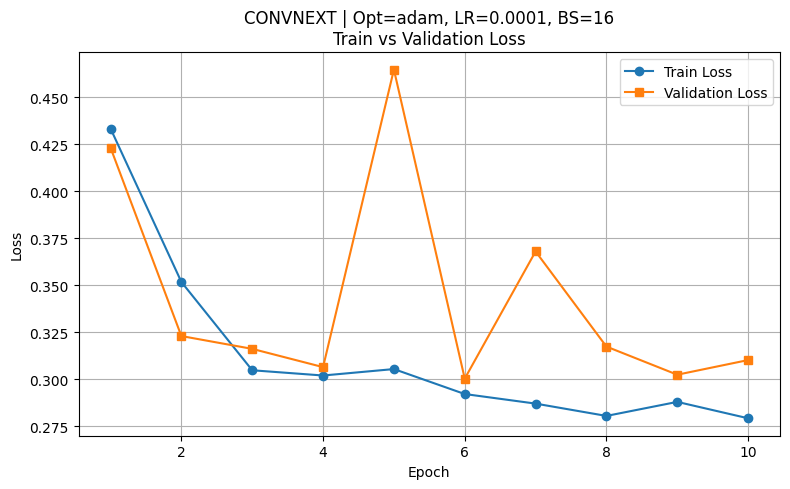

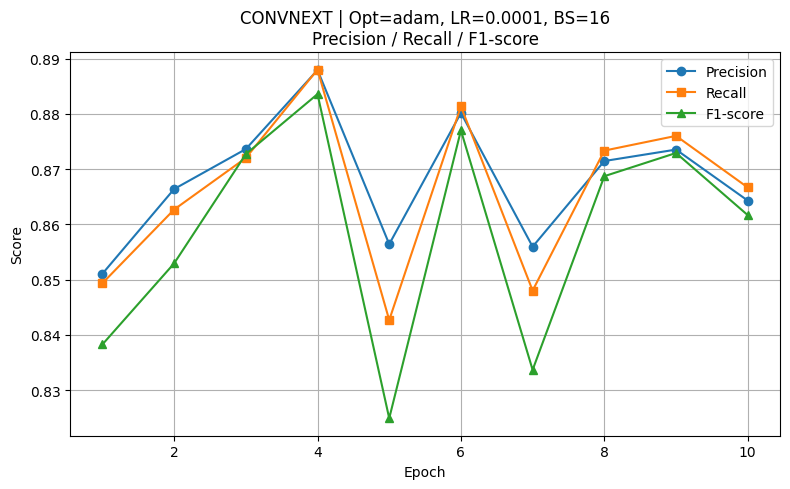


Eksperiment 2
Optimizer = adam, LR = 0.0001, Batch Size = 32
Epoch 1/10 | Train Loss: 0.4297 | Val Loss: 0.3515 | Precision: 0.8621 | Recall: 0.8640 | F1: 0.8628
   ✅ Save: results/convnext_adam_lr0.0001_bs32_best.pth
Epoch 2/10 | Train Loss: 0.3402 | Val Loss: 0.3235 | Precision: 0.8774 | Recall: 0.8787 | F1: 0.8779
   ✅ Save: results/convnext_adam_lr0.0001_bs32_best.pth
Epoch 3/10 | Train Loss: 0.2874 | Val Loss: 0.3124 | Precision: 0.8734 | Recall: 0.8747 | F1: 0.8739
Epoch 4/10 | Train Loss: 0.2848 | Val Loss: 0.3236 | Precision: 0.8651 | Recall: 0.8680 | F1: 0.8645
Epoch 5/10 | Train Loss: 0.2607 | Val Loss: 0.3214 | Precision: 0.8707 | Recall: 0.8733 | F1: 0.8702
Epoch 6/10 | Train Loss: 0.2728 | Val Loss: 0.3060 | Precision: 0.8831 | Recall: 0.8840 | F1: 0.8798
   ✅ Save: results/convnext_adam_lr0.0001_bs32_best.pth
Epoch 7/10 | Train Loss: 0.2552 | Val Loss: 0.2972 | Precision: 0.8721 | Recall: 0.8747 | F1: 0.8716
Epoch 8/10 | Train Loss: 0.2520 | Val Loss: 0.3009 | Precision:

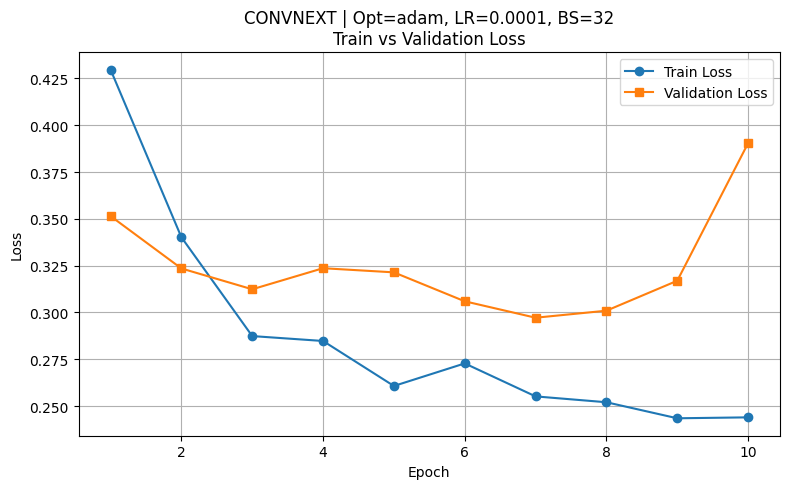

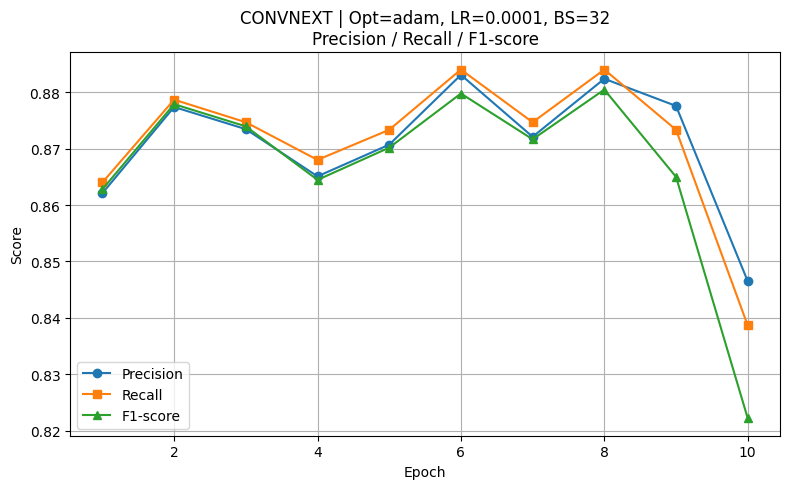


Eksperiment 3
Optimizer = adam, LR = 5e-05, Batch Size = 16
Epoch 1/10 | Train Loss: 0.4224 | Val Loss: 0.3617 | Precision: 0.8583 | Recall: 0.8613 | F1: 0.8564
   ✅ Save: results/convnext_adam_lr5e-05_bs16_best.pth
Epoch 2/10 | Train Loss: 0.3315 | Val Loss: 0.3180 | Precision: 0.8706 | Recall: 0.8680 | F1: 0.8596
   ✅ Save: results/convnext_adam_lr5e-05_bs16_best.pth
Epoch 3/10 | Train Loss: 0.2881 | Val Loss: 0.3313 | Precision: 0.8803 | Recall: 0.8760 | F1: 0.8775
   ✅ Save: results/convnext_adam_lr5e-05_bs16_best.pth
Epoch 4/10 | Train Loss: 0.2716 | Val Loss: 0.2940 | Precision: 0.8777 | Recall: 0.8800 | F1: 0.8775
   ✅ Save: results/convnext_adam_lr5e-05_bs16_best.pth
Epoch 5/10 | Train Loss: 0.2592 | Val Loss: 0.3236 | Precision: 0.8728 | Recall: 0.8747 | F1: 0.8702
Epoch 6/10 | Train Loss: 0.2547 | Val Loss: 0.2930 | Precision: 0.8905 | Recall: 0.8907 | F1: 0.8866
   ✅ Save: results/convnext_adam_lr5e-05_bs16_best.pth
Epoch 7/10 | Train Loss: 0.2366 | Val Loss: 0.3563 | Preci

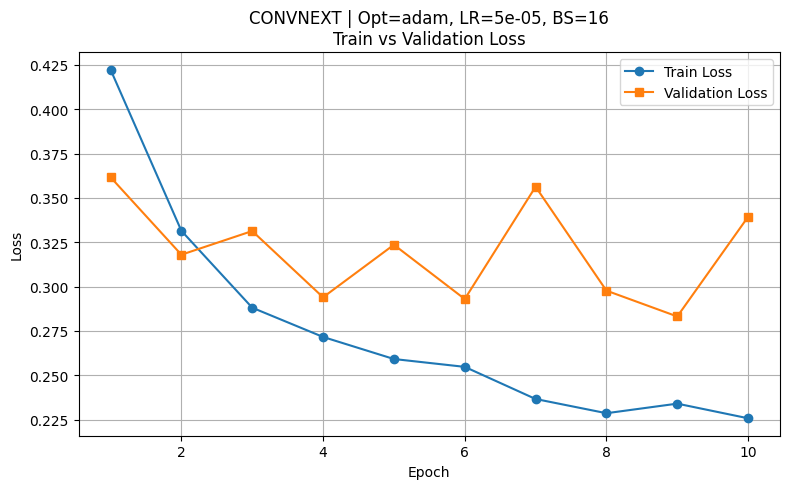

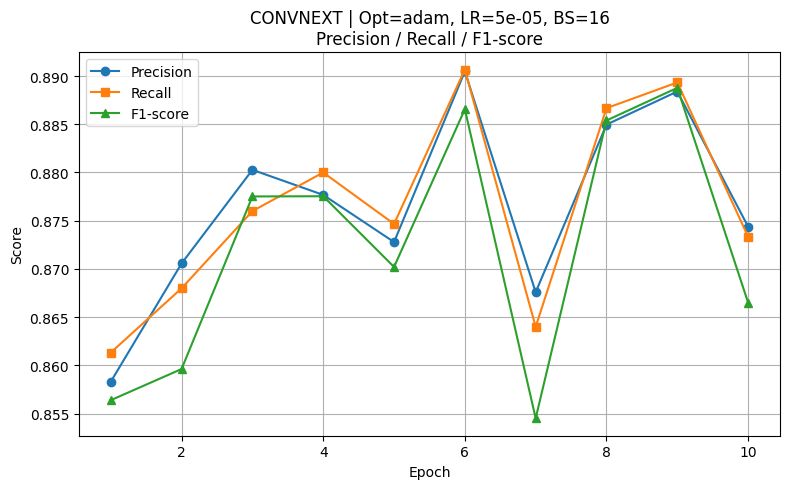


Eksperiment 4
Optimizer = adam, LR = 5e-05, Batch Size = 32
Epoch 1/10 | Train Loss: 0.4303 | Val Loss: 0.3490 | Precision: 0.8571 | Recall: 0.8600 | F1: 0.8577
   ✅ Save: results/convnext_adam_lr5e-05_bs32_best.pth
Epoch 2/10 | Train Loss: 0.3359 | Val Loss: 0.3115 | Precision: 0.8721 | Recall: 0.8747 | F1: 0.8719
   ✅ Save: results/convnext_adam_lr5e-05_bs32_best.pth
Epoch 3/10 | Train Loss: 0.2864 | Val Loss: 0.3204 | Precision: 0.8743 | Recall: 0.8733 | F1: 0.8738
   ✅ Save: results/convnext_adam_lr5e-05_bs32_best.pth
Epoch 4/10 | Train Loss: 0.2745 | Val Loss: 0.3033 | Precision: 0.8750 | Recall: 0.8773 | F1: 0.8752
   ✅ Save: results/convnext_adam_lr5e-05_bs32_best.pth
Epoch 5/10 | Train Loss: 0.2490 | Val Loss: 0.2887 | Precision: 0.8890 | Recall: 0.8907 | F1: 0.8880
   ✅ Save: results/convnext_adam_lr5e-05_bs32_best.pth
Epoch 6/10 | Train Loss: 0.2543 | Val Loss: 0.2939 | Precision: 0.8839 | Recall: 0.8853 | F1: 0.8817
Epoch 7/10 | Train Loss: 0.2363 | Val Loss: 0.3292 | Preci

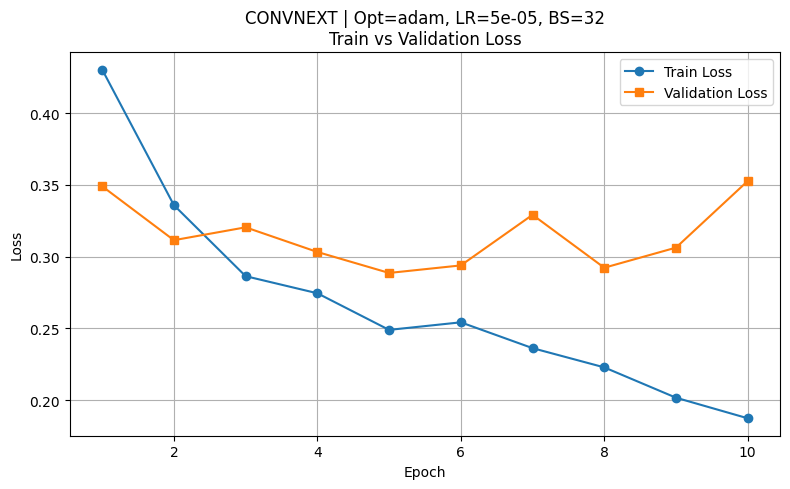

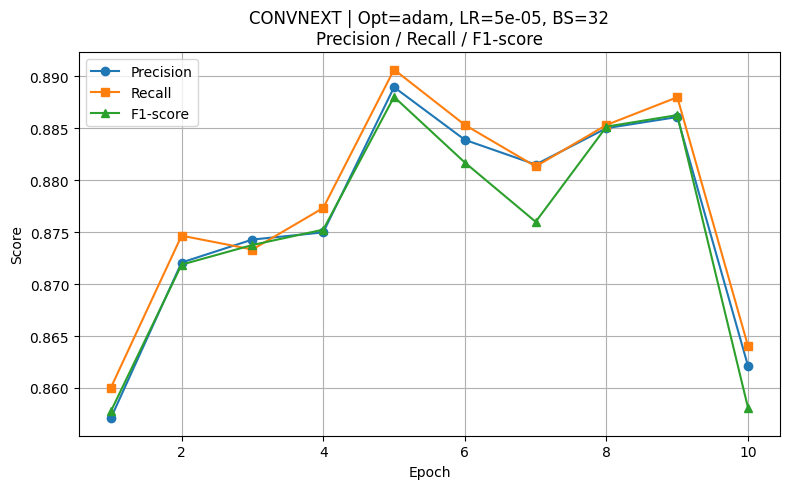


Eksperiment 5
Optimizer = sgd, LR = 0.0001, Batch Size = 16
Epoch 1/10 | Train Loss: 0.5395 | Val Loss: 0.5186 | Precision: 0.7770 | Recall: 0.7587 | F1: 0.6991
   ✅ Save: results/convnext_sgd_lr0.0001_bs16_best.pth
Epoch 2/10 | Train Loss: 0.4680 | Val Loss: 0.4448 | Precision: 0.7883 | Recall: 0.7973 | F1: 0.7822
   ✅ Save: results/convnext_sgd_lr0.0001_bs16_best.pth
Epoch 3/10 | Train Loss: 0.4300 | Val Loss: 0.4223 | Precision: 0.8177 | Recall: 0.8240 | F1: 0.8163
   ✅ Save: results/convnext_sgd_lr0.0001_bs16_best.pth
Epoch 4/10 | Train Loss: 0.3963 | Val Loss: 0.4056 | Precision: 0.8221 | Recall: 0.8173 | F1: 0.7964
Epoch 5/10 | Train Loss: 0.3767 | Val Loss: 0.4214 | Precision: 0.8253 | Recall: 0.8227 | F1: 0.8046
Epoch 6/10 | Train Loss: 0.3627 | Val Loss: 0.3827 | Precision: 0.8396 | Recall: 0.8373 | F1: 0.8234
   ✅ Save: results/convnext_sgd_lr0.0001_bs16_best.pth
Epoch 7/10 | Train Loss: 0.3403 | Val Loss: 0.4041 | Precision: 0.8442 | Recall: 0.8373 | F1: 0.8210
Epoch 8/10 |

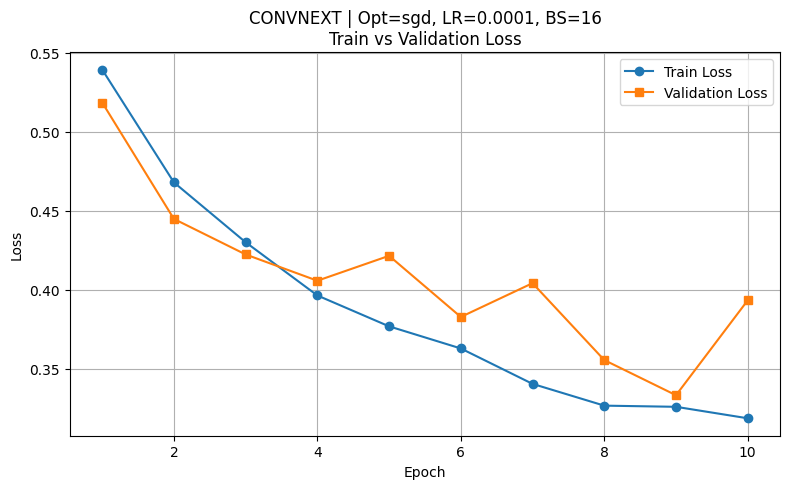

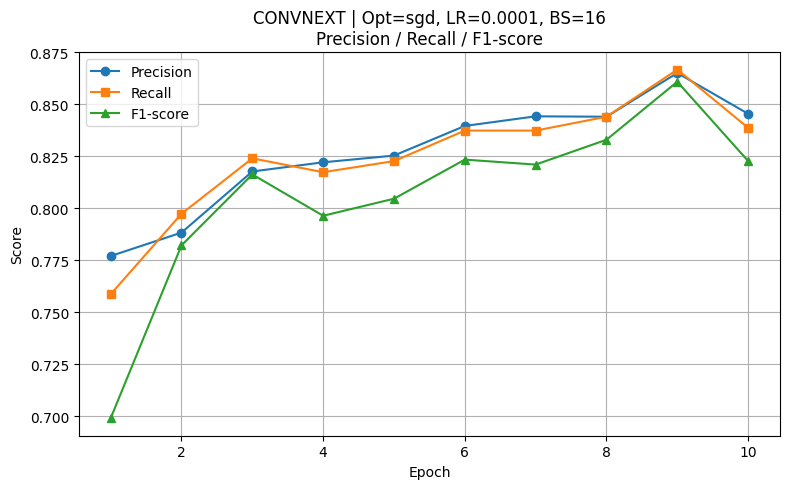


Eksperiment 6
Optimizer = sgd, LR = 0.0001, Batch Size = 32
Epoch 1/10 | Train Loss: 0.5696 | Val Loss: 0.5340 | Precision: 0.7995 | Recall: 0.7213 | F1: 0.6111
   ✅ Save: results/convnext_sgd_lr0.0001_bs32_best.pth
Epoch 2/10 | Train Loss: 0.5039 | Val Loss: 0.4855 | Precision: 0.7860 | Recall: 0.7813 | F1: 0.7446
   ✅ Save: results/convnext_sgd_lr0.0001_bs32_best.pth
Epoch 3/10 | Train Loss: 0.4671 | Val Loss: 0.4617 | Precision: 0.7967 | Recall: 0.7947 | F1: 0.7665
   ✅ Save: results/convnext_sgd_lr0.0001_bs32_best.pth
Epoch 4/10 | Train Loss: 0.4348 | Val Loss: 0.4485 | Precision: 0.7989 | Recall: 0.7987 | F1: 0.7736
   ✅ Save: results/convnext_sgd_lr0.0001_bs32_best.pth
Epoch 5/10 | Train Loss: 0.4096 | Val Loss: 0.4234 | Precision: 0.8120 | Recall: 0.8093 | F1: 0.7868
   ✅ Save: results/convnext_sgd_lr0.0001_bs32_best.pth
Epoch 6/10 | Train Loss: 0.4021 | Val Loss: 0.4500 | Precision: 0.8296 | Recall: 0.8027 | F1: 0.7670
Epoch 7/10 | Train Loss: 0.3885 | Val Loss: 0.4134 | Preci

In [ ]:
model_name = 'convnext'  # baseline, densenet, resnet, efficientnet, inception, vgg, convnext
epochs = 10
seed = 42

image_dir = "/content/drive/MyDrive/data/TN5000_forReview/JPEGImages"
annotation_dir = "/content/drive/MyDrive/data/TN5000_forReview/Annotations"

best_config, best_model_path, results_df = run_automl(
    model_name=model_name,
    image_dir=image_dir,
    annotation_dir=annotation_dir,
    device=device,
    epochs=epochs,
    seed=seed
)

print("\nNajbolja konfiguracija AutoML-a:")
print(best_config)
print("Putanja do najboljeg modela:", best_model_path)

# AutoML / Grid Search Rezultati - ConvNeXt Tiny

## Opis eksperimenata
AutoML Grid Search je izveden za **ConvNeXt Tiny** model na datasetu TN5000.  
Testirane su različite kombinacije hiperparametara:

- **Optimizatori:** Adam i SGD  
- **Learning Rate:** 0.0001 i 5e-05  
- **Batch Size:** 16 i 32  

Cilj je bio maksimizirati **F1-score**.

---

## Eksperimenti i detaljni rezultati

### Eksperiment 1: Adam, LR=0.0001, BS=16
| Epoch | Train Loss | Val Loss | Precision | Recall | F1-score |
|-------|------------|----------|-----------|--------|----------|
| 1 | 0.4333 | 0.4231 | 0.8510 | 0.8493 | 0.8383 |
| 2 | 0.3517 | 0.3230 | 0.8664 | 0.8627 | 0.8529 |
| 3 | 0.3048 | 0.3162 | 0.8736 | 0.8720 | 0.8727 |
| 4 | 0.3020 | 0.3065 | 0.8879 | 0.8880 | 0.8836 ✅ |
| 5 | 0.3054 | 0.4646 | 0.8564 | 0.8427 | 0.8249 |
| 6 | 0.2922 | 0.3003 | 0.8802 | 0.8813 | 0.8770 |
| 7 | 0.2871 | 0.3679 | 0.8559 | 0.8480 | 0.8336 |
| 8 | 0.2805 | 0.3174 | 0.8714 | 0.8733 | 0.8687 |
| 9 | 0.2880 | 0.3024 | 0.8735 | 0.8760 | 0.8729 |
| 10 | 0.2793 | 0.3102 | 0.8643 | 0.8667 | 0.8617 |

---

### Eksperiment 2: Adam, LR=0.0001, BS=32
| Epoch | Train Loss | Val Loss | Precision | Recall | F1-score |
|-------|------------|----------|-----------|--------|----------|
| 1 | 0.4297 | 0.3515 | 0.8621 | 0.8640 | 0.8628 |
| 2 | 0.3402 | 0.3235 | 0.8774 | 0.8787 | 0.8779 |
| 3 | 0.2874 | 0.3124 | 0.8734 | 0.8747 | 0.8739 |
| 4 | 0.2848 | 0.3236 | 0.8651 | 0.8680 | 0.8645 |
| 5 | 0.2607 | 0.3214 | 0.8707 | 0.8733 | 0.8702 |
| 6 | 0.2728 | 0.3060 | 0.8831 | 0.8840 | 0.8798 ✅ |
| 7 | 0.2552 | 0.2972 | 0.8721 | 0.8747 | 0.8716 |
| 8 | 0.2520 | 0.3009 | 0.8824 | 0.8840 | 0.8804 |
| 9 | 0.2435 | 0.3169 | 0.8776 | 0.8733 | 0.8650 |
| 10 | 0.2440 | 0.3904 | 0.8465 | 0.8387 | 0.8222 |

---

### Eksperiment 3: Adam, LR=5e-05, BS=16
| Epoch | Train Loss | Val Loss | Precision | Recall | F1-score |
|-------|------------|----------|-----------|--------|----------|
| 1 | 0.4224 | 0.3617 | 0.8583 | 0.8613 | 0.8564 |
| 2 | 0.3315 | 0.3180 | 0.8706 | 0.8680 | 0.8596 |
| 3 | 0.2881 | 0.3313 | 0.8803 | 0.8760 | 0.8775 |
| 4 | 0.2716 | 0.2940 | 0.8777 | 0.8800 | 0.8775 |
| 5 | 0.2592 | 0.3236 | 0.8728 | 0.8747 | 0.8702 |
| 6 | 0.2547 | 0.2930 | 0.8905 | 0.8907 | 0.8866 |
| 7 | 0.2366 | 0.3563 | 0.8676 | 0.8640 | 0.8545 |
| 8 | 0.2286 | 0.2977 | 0.8850 | 0.8867 | 0.8854 |
| 9 | 0.2340 | 0.2831 | 0.8884 | 0.8893 | 0.8888 ✅ |
| 10 | 0.2257 | 0.3394 | 0.8744 | 0.8733 | 0.8665 |

---

### Eksperiment 4: Adam, LR=5e-05, BS=32
| Epoch | Train Loss | Val Loss | Precision | Recall | F1-score |
|-------|------------|----------|-----------|--------|----------|
| 1 | 0.4303 | 0.3490 | 0.8571 | 0.8600 | 0.8577 |
| 2 | 0.3359 | 0.3115 | 0.8721 | 0.8747 | 0.8719 |
| 3 | 0.2864 | 0.3204 | 0.8743 | 0.8733 | 0.8738 |
| 4 | 0.2745 | 0.3033 | 0.8750 | 0.8773 | 0.8752 |
| 5 | 0.2490 | 0.2887 | 0.8890 | 0.8907 | 0.8880 |
| 6 | 0.2543 | 0.2939 | 0.8839 | 0.8853 | 0.8817 |
| 7 | 0.2363 | 0.3292 | 0.8815 | 0.8813 | 0.8760 |
| 8 | 0.2229 | 0.2923 | 0.8850 | 0.8853 | 0.8852 |
| 9 | 0.2018 | 0.3063 | 0.8861 | 0.8880 | 0.8863 |
| 10 | 0.1874 | 0.3527 | 0.8621 | 0.8640 | 0.8580 |

---

### Eksperiment 5: SGD, LR=0.0001, BS=16
| Epoch | Train Loss | Val Loss | Precision | Recall | F1-score |
|-------|------------|----------|-----------|--------|----------|
| 1 | 0.5395 | 0.5186 | 0.7770 | 0.7587 | 0.6991 |
| 2 | 0.4680 | 0.4448 | 0.7883 | 0.7973 | 0.7822 |
| 3 | 0.4300 | 0.4223 | 0.8177 | 0.8240 | 0.8163 |
| 4 | 0.3963 | 0.4056 | 0.8221 | 0.8173 | 0.7964 |
| 5 | 0.3767 | 0.4214 | 0.8253 | 0.8227 | 0.8046 |
| 6 | 0.3627 | 0.3827 | 0.8396 | 0.8373 | 0.8234 |
| 7 | 0.3403 | 0.4041 | 0.8442 | 0.8373 | 0.8210 |
| 8 | 0.3265 | 0.3554 | 0.8440 | 0.8440 | 0.8329 |
| 9 | 0.3257 | 0.3331 | 0.8650 | 0.8667 | 0.8608 ✅ |
| 10 | 0.3185 | 0.3932 | 0.8454 | 0.8387 | 0.8227 |

---

### Eksperiment 6: SGD, LR=0.0001, BS=32
| Epoch | Train Loss | Val Loss | Precision | Recall | F1-score |
|-------|------------|----------|-----------|--------|----------|
| 1 | 0.5696 | 0.5340 | 0.7995 | 0.7213 | 0.6111 |
| 2 | 0.5039 | 0.4855 | 0.7860 | 0.7813 | 0.7446 |
| 3 | 0.4671 | 0.4617 | 0.7967 | 0.7947 | 0.7665 |
| 4 | 0.4348 | 0.4485 | 0.7989 | 0.7987 | 0.7736 |
| 5 | 0.4096 | 0.4234 | 0.8120 | 0.8093 | 0.7868 |
| 6 | 0.4021 | 0.4500 | 0.8296 | 0.8027 | 0.7670 |
| 7 | 0.3885 | 0.4134 | 0.8257 | 0.8173 | 0.7946 |
| 8 | 0.3700 | 0.3757 | 0.8357 | 0.8373 | 0.8260 ✅ |
| 9 | 0.3518 | 0.3798 | 0.8444 | 0.8387 | 0.8232 |

---

## Zaključak
Najbolja konfiguracija dobijena AutoML-om:

- **Optimizer:** Adam  
- **Learning Rate:** 5e-05  
- **Batch Size:** 16  
- **Precision:** 0.8844  
- **Recall:** 0.8893
- **Najbolji F1-score:** 0.8888  

**Napomena:** Proces nije stigao do kraja svih kombinacija zbog **ograničenja resursa na Colabu**, ali rezultati jasno pokazuju da je Adam optimizator sa manjim learning rate-om i batch size 16 najefikasniji za ovaj dataset.

## Pokretanje AutoML optimizacije za InceptionV3 model

U ovom koraku pokrenuta je **AutoML optimizacija hiperparametara** za model **InceptionV3**, pri čemu je promenljiva `model_name` postavljena na vrednost `'inception'`.

Broj epoha postavljen je na **10**, što znači da se svaka ispitivana konfiguracija trenira tokom deset prolaza kroz trening skup, dok je vrednost `seed = 42` korišćena radi obezbeđivanja **reproduktivnosti rezultata**. Takođe, definisane su putanje do direktorijuma sa slikama (`JPEGImages`) i pripadajućim XML anotacijama (`Annotations`) iz skupa podataka **TN5000_forReview**.

Pozivom funkcije `run_automl(...)` pokreće se kompletan proces automatske optimizacije, koji obuhvata:
- izbor i kreiranje odgovarajućeg modela,
- pripremu podataka,
- treniranje više kombinacija hiperparametara,
- evaluaciju svake konfiguracije,
- izbor najbolje konfiguracije na osnovu definisane metrike performansi.

Kao rezultat izvršavanja, funkcija vraća:
- `best_config` – najbolju pronađenu kombinaciju hiperparametara,
- `best_model_path` – putanju do sačuvanog najboljeg modela,
- `results_df` – tabelarni prikaz rezultata svih testiranih konfiguracija.

Na kraju se ispisuje **najbolja AutoML konfiguracija** i **putanja do modela** koji je ostvario najbolje performanse, čime se omogućava dalja analiza ili ponovno učitavanje modela za finalnu evaluaciju.


===== POKRETANJE AutoML / Grid Search =====


Eksperiment 1
Optimizer = adam, LR = 0.001, Batch Size = 16
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 169MB/s] 


Epoch 1/10 | Train Loss: 0.7730 | Val Loss: 0.5590 | Precision: 0.7204 | Recall: 0.7413 | F1: 0.7220
   ✅ Save: results/inception_adam_lr0.001_bs16_best.pth
Epoch 2/10 | Train Loss: 0.7627 | Val Loss: 0.5348 | Precision: 0.7469 | Recall: 0.7587 | F1: 0.7186
Epoch 3/10 | Train Loss: 0.7377 | Val Loss: 0.5256 | Precision: 0.7778 | Recall: 0.7533 | F1: 0.6868
Epoch 4/10 | Train Loss: 0.7500 | Val Loss: 0.5333 | Precision: 0.7551 | Recall: 0.7480 | F1: 0.6829
Epoch 5/10 | Train Loss: 0.7521 | Val Loss: 0.5577 | Precision: 0.7976 | Recall: 0.7413 | F1: 0.6558
Epoch 6/10 | Train Loss: 0.7413 | Val Loss: 0.5297 | Precision: 0.7323 | Recall: 0.7467 | F1: 0.7361
   ✅ Save: results/inception_adam_lr0.001_bs16_best.pth
Epoch 7/10 | Train Loss: 0.7318 | Val Loss: 0.5315 | Precision: 0.7710 | Recall: 0.7627 | F1: 0.7109
Epoch 8/10 | Train Loss: 0.7655 | Val Loss: 0.5188 | Precision: 0.7829 | Recall: 0.7573 | F1: 0.6940
Epoch 9/10 | Train Loss: 0.7470 | Val Loss: 0.5139 | Precision: 0.7692 | Recall:

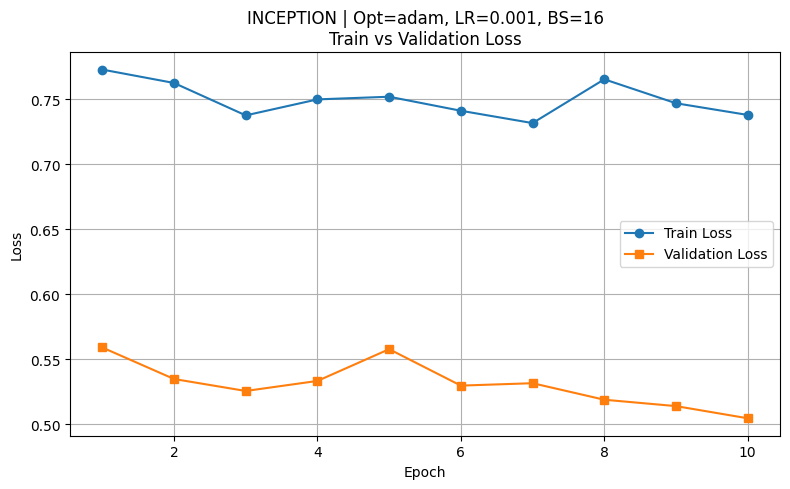

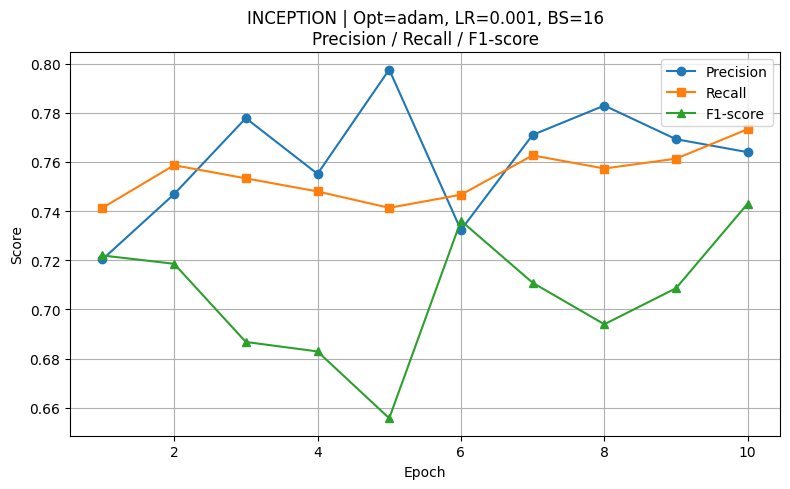


Eksperiment 2
Optimizer = adam, LR = 0.001, Batch Size = 32
Epoch 1/10 | Train Loss: 0.7691 | Val Loss: 0.5639 | Precision: 0.7884 | Recall: 0.7333 | F1: 0.6393
   ✅ Save: results/inception_adam_lr0.001_bs32_best.pth
Epoch 2/10 | Train Loss: 0.7214 | Val Loss: 0.5475 | Precision: 0.7488 | Recall: 0.7360 | F1: 0.6541
   ✅ Save: results/inception_adam_lr0.001_bs32_best.pth
Epoch 3/10 | Train Loss: 0.7131 | Val Loss: 0.5352 | Precision: 0.7889 | Recall: 0.7427 | F1: 0.6602
   ✅ Save: results/inception_adam_lr0.001_bs32_best.pth
Epoch 4/10 | Train Loss: 0.7027 | Val Loss: 0.5177 | Precision: 0.7744 | Recall: 0.7653 | F1: 0.7153
   ✅ Save: results/inception_adam_lr0.001_bs32_best.pth
Epoch 5/10 | Train Loss: 0.7013 | Val Loss: 0.5397 | Precision: 0.7516 | Recall: 0.7440 | F1: 0.6742
Epoch 6/10 | Train Loss: 0.7088 | Val Loss: 0.5359 | Precision: 0.7778 | Recall: 0.7533 | F1: 0.6868
Epoch 7/10 | Train Loss: 0.6961 | Val Loss: 0.5361 | Precision: 0.7936 | Recall: 0.7533 | F1: 0.6823
Epoch 8/

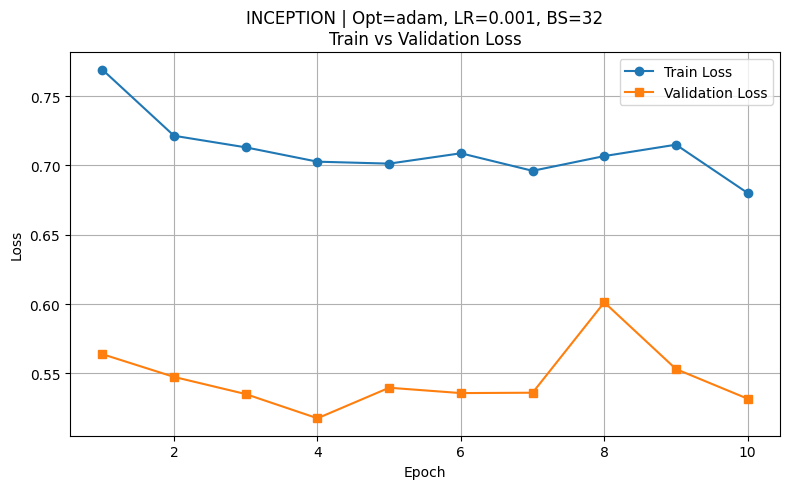

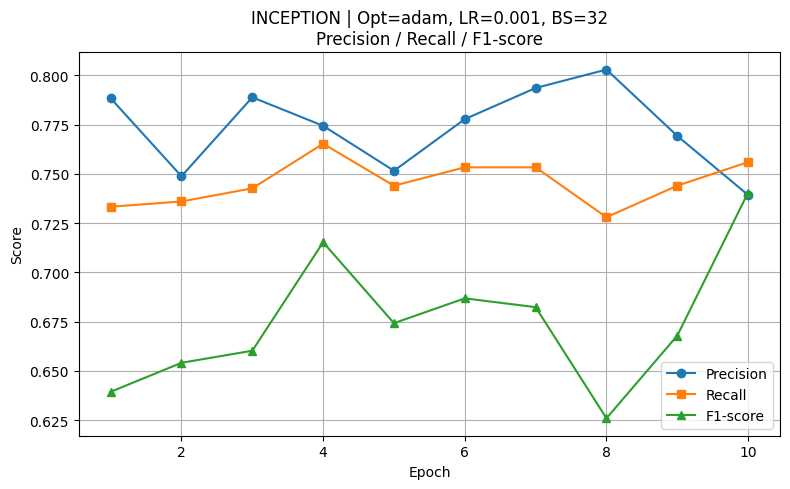


Eksperiment 3
Optimizer = adam, LR = 0.0001, Batch Size = 16
Epoch 1/10 | Train Loss: 0.8493 | Val Loss: 0.5903 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
   ✅ Save: results/inception_adam_lr0.0001_bs16_best.pth
Epoch 2/10 | Train Loss: 0.7809 | Val Loss: 0.5770 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
Epoch 3/10 | Train Loss: 0.7526 | Val Loss: 0.5625 | Precision: 0.8009 | Recall: 0.7240 | F1: 0.6171
   ✅ Save: results/inception_adam_lr0.0001_bs16_best.pth
Epoch 4/10 | Train Loss: 0.7264 | Val Loss: 0.5588 | Precision: 0.8016 | Recall: 0.7253 | F1: 0.6200
   ✅ Save: results/inception_adam_lr0.0001_bs16_best.pth
Epoch 5/10 | Train Loss: 0.7302 | Val Loss: 0.5547 | Precision: 0.7671 | Recall: 0.7347 | F1: 0.6460
   ✅ Save: results/inception_adam_lr0.0001_bs16_best.pth
Epoch 6/10 | Train Loss: 0.7079 | Val Loss: 0.5529 | Precision: 0.8037 | Recall: 0.7293 | F1: 0.6288
Epoch 7/10 | Train Loss: 0.7015 | Val Loss: 0.5461 | Precision: 0.7855 | Recall: 0.7400 | F1: 0.6549
   

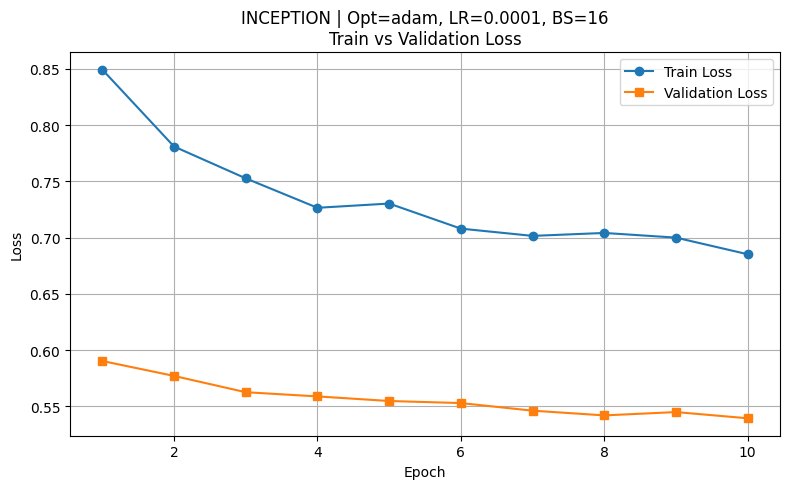

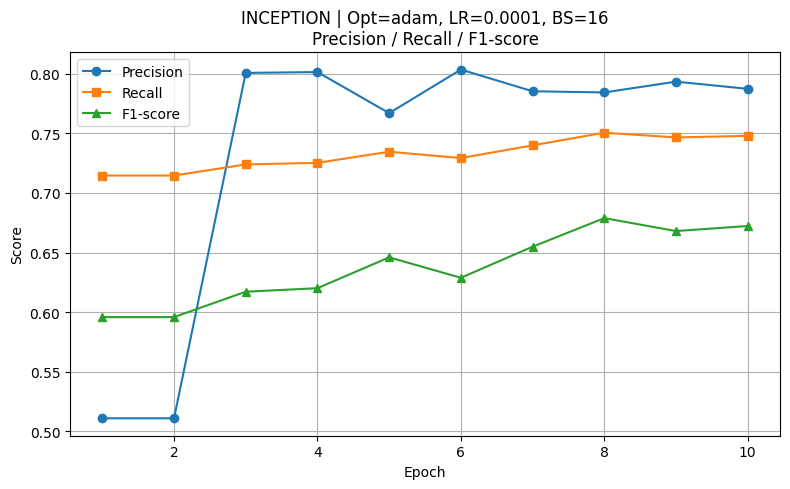


Eksperiment 4
Optimizer = adam, LR = 0.0001, Batch Size = 32
Epoch 1/10 | Train Loss: 0.8608 | Val Loss: 0.5970 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
   ✅ Save: results/inception_adam_lr0.0001_bs32_best.pth
Epoch 2/10 | Train Loss: 0.7966 | Val Loss: 0.5808 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
Epoch 3/10 | Train Loss: 0.7658 | Val Loss: 0.5701 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
Epoch 4/10 | Train Loss: 0.7430 | Val Loss: 0.5634 | Precision: 0.7995 | Recall: 0.7213 | F1: 0.6111
   ✅ Save: results/inception_adam_lr0.0001_bs32_best.pth
Epoch 5/10 | Train Loss: 0.7293 | Val Loss: 0.5599 | Precision: 0.7995 | Recall: 0.7213 | F1: 0.6111
Epoch 6/10 | Train Loss: 0.7187 | Val Loss: 0.5544 | Precision: 0.8009 | Recall: 0.7240 | F1: 0.6171
   ✅ Save: results/inception_adam_lr0.0001_bs32_best.pth
Epoch 7/10 | Train Loss: 0.7063 | Val Loss: 0.5494 | Precision: 0.7948 | Recall: 0.7387 | F1: 0.6504
   ✅ Save: results/inception_adam_lr0.0001_bs32_best.pth
Epo

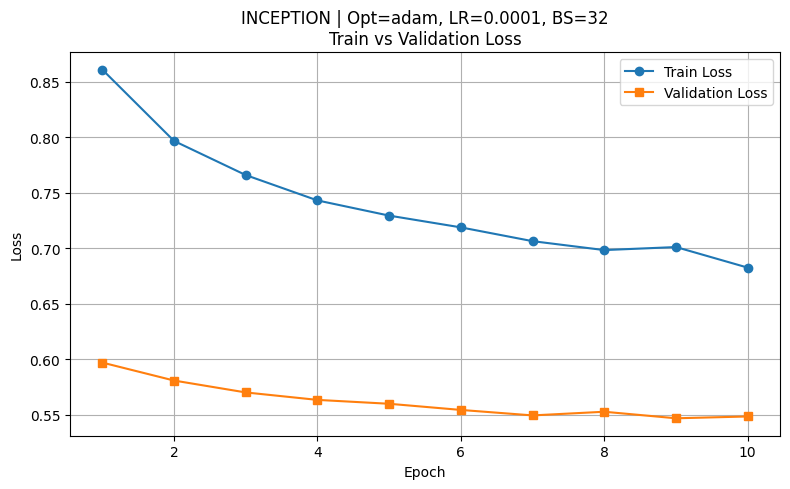

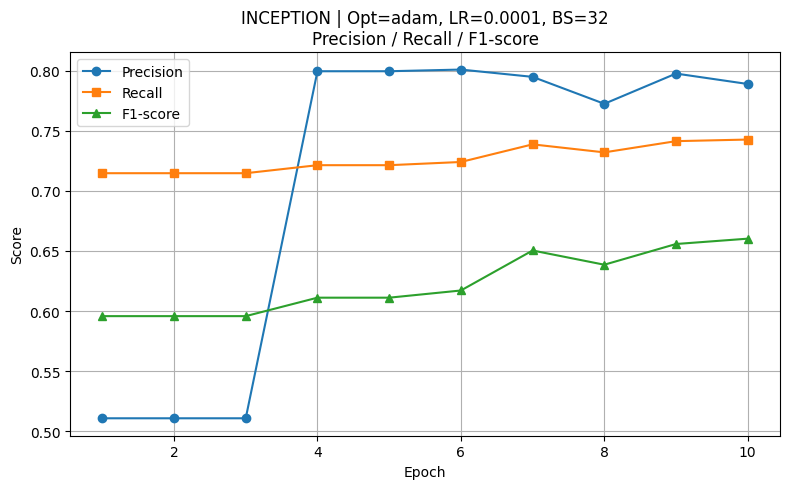


Eksperiment 5
Optimizer = sgd, LR = 0.001, Batch Size = 16
Epoch 1/10 | Train Loss: 0.7749 | Val Loss: 0.5479 | Precision: 0.7299 | Recall: 0.7480 | F1: 0.7040
   ✅ Save: results/inception_sgd_lr0.001_bs16_best.pth
Epoch 2/10 | Train Loss: 0.7433 | Val Loss: 0.5376 | Precision: 0.7496 | Recall: 0.7600 | F1: 0.7196
   ✅ Save: results/inception_sgd_lr0.001_bs16_best.pth
Epoch 3/10 | Train Loss: 0.7206 | Val Loss: 0.5270 | Precision: 0.7858 | Recall: 0.7560 | F1: 0.6902
Epoch 4/10 | Train Loss: 0.7224 | Val Loss: 0.5401 | Precision: 0.7733 | Recall: 0.7427 | F1: 0.6636
Epoch 5/10 | Train Loss: 0.7287 | Val Loss: 0.5561 | Precision: 0.7934 | Recall: 0.7373 | F1: 0.6476
Epoch 6/10 | Train Loss: 0.7208 | Val Loss: 0.5183 | Precision: 0.7480 | Recall: 0.7600 | F1: 0.7216
   ✅ Save: results/inception_sgd_lr0.001_bs16_best.pth
Epoch 7/10 | Train Loss: 0.7068 | Val Loss: 0.5200 | Precision: 0.7704 | Recall: 0.7707 | F1: 0.7302
   ✅ Save: results/inception_sgd_lr0.001_bs16_best.pth
Epoch 8/10 | 

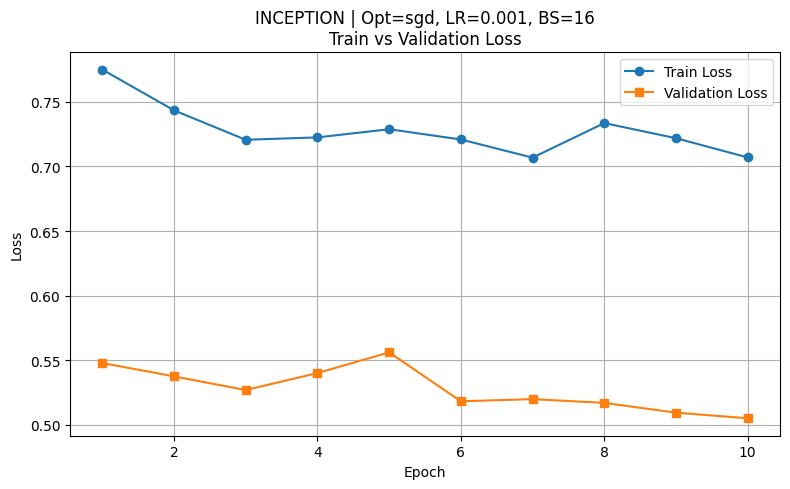

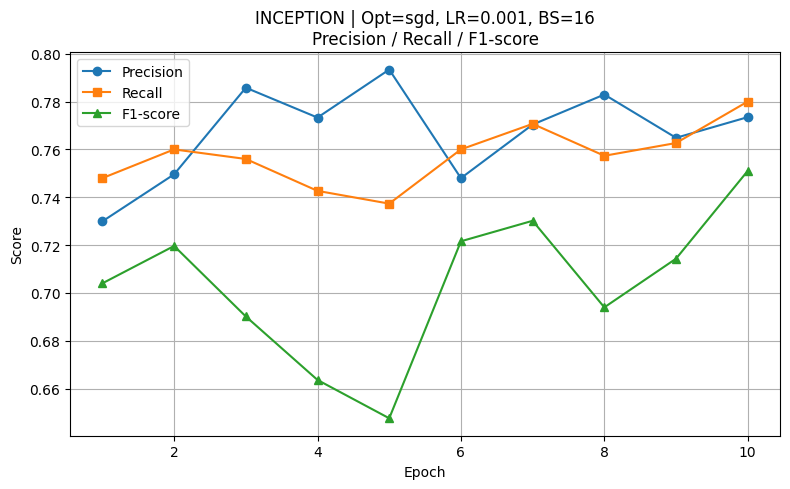


Eksperiment 6
Optimizer = sgd, LR = 0.001, Batch Size = 32
Epoch 1/10 | Train Loss: 0.7865 | Val Loss: 0.5602 | Precision: 0.7549 | Recall: 0.7253 | F1: 0.6244
   ✅ Save: results/inception_sgd_lr0.001_bs32_best.pth
Epoch 2/10 | Train Loss: 0.7220 | Val Loss: 0.5806 | Precision: 0.7988 | Recall: 0.7200 | F1: 0.6081
Epoch 3/10 | Train Loss: 0.7037 | Val Loss: 0.5294 | Precision: 0.7526 | Recall: 0.7573 | F1: 0.7091
   ✅ Save: results/inception_sgd_lr0.001_bs32_best.pth
Epoch 4/10 | Train Loss: 0.6921 | Val Loss: 0.5257 | Precision: 0.7855 | Recall: 0.7627 | F1: 0.7047
Epoch 5/10 | Train Loss: 0.6876 | Val Loss: 0.5301 | Precision: 0.7596 | Recall: 0.7560 | F1: 0.7009
Epoch 6/10 | Train Loss: 0.6869 | Val Loss: 0.5228 | Precision: 0.7667 | Recall: 0.7627 | F1: 0.7132
   ✅ Save: results/inception_sgd_lr0.001_bs32_best.pth
Epoch 7/10 | Train Loss: 0.6765 | Val Loss: 0.5191 | Precision: 0.7612 | Recall: 0.7600 | F1: 0.7100
Epoch 8/10 | Train Loss: 0.6795 | Val Loss: 0.5263 | Precision: 0.73

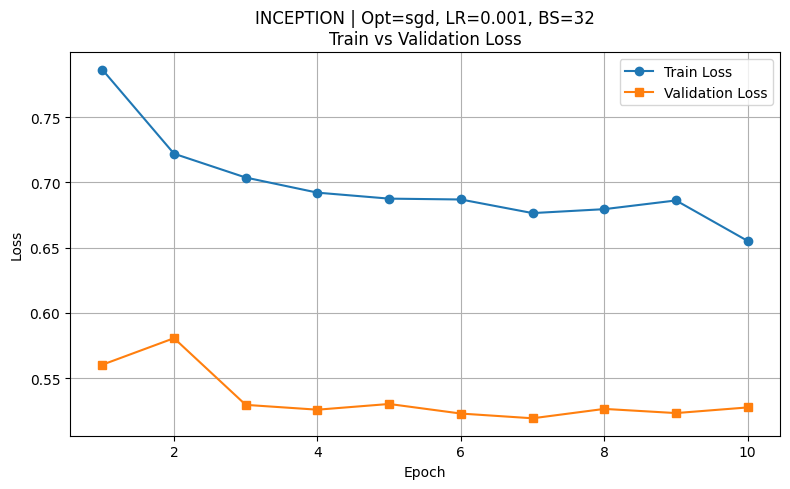

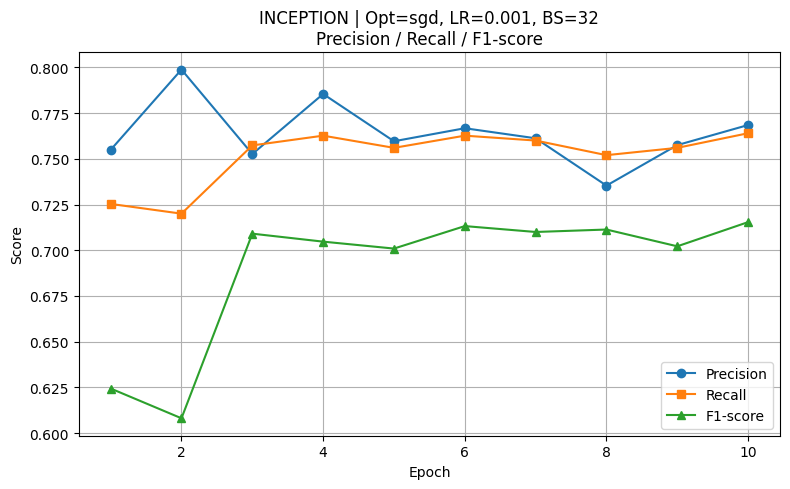


Eksperiment 7
Optimizer = sgd, LR = 0.0001, Batch Size = 16
Epoch 1/10 | Train Loss: 0.8655 | Val Loss: 0.5955 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
   ✅ Save: results/inception_sgd_lr0.0001_bs16_best.pth
Epoch 2/10 | Train Loss: 0.7962 | Val Loss: 0.5801 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
Epoch 3/10 | Train Loss: 0.7686 | Val Loss: 0.5678 | Precision: 0.7988 | Recall: 0.7200 | F1: 0.6081
   ✅ Save: results/inception_sgd_lr0.0001_bs16_best.pth
Epoch 4/10 | Train Loss: 0.7409 | Val Loss: 0.5638 | Precision: 0.7995 | Recall: 0.7213 | F1: 0.6111
   ✅ Save: results/inception_sgd_lr0.0001_bs16_best.pth
Epoch 5/10 | Train Loss: 0.7428 | Val Loss: 0.5604 | Precision: 0.8016 | Recall: 0.7253 | F1: 0.6200
   ✅ Save: results/inception_sgd_lr0.0001_bs16_best.pth
Epoch 6/10 | Train Loss: 0.7219 | Val Loss: 0.5585 | Precision: 0.8002 | Recall: 0.7227 | F1: 0.6141
Epoch 7/10 | Train Loss: 0.7149 | Val Loss: 0.5511 | Precision: 0.8065 | Recall: 0.7347 | F1: 0.6402
   ✅ Sav

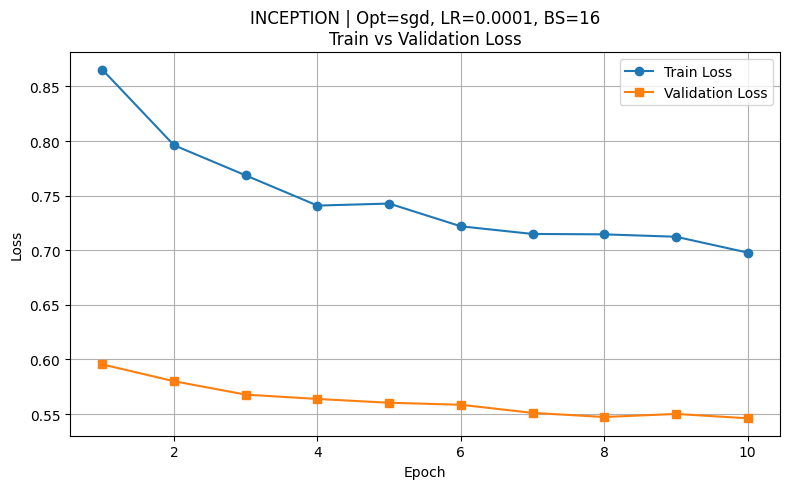

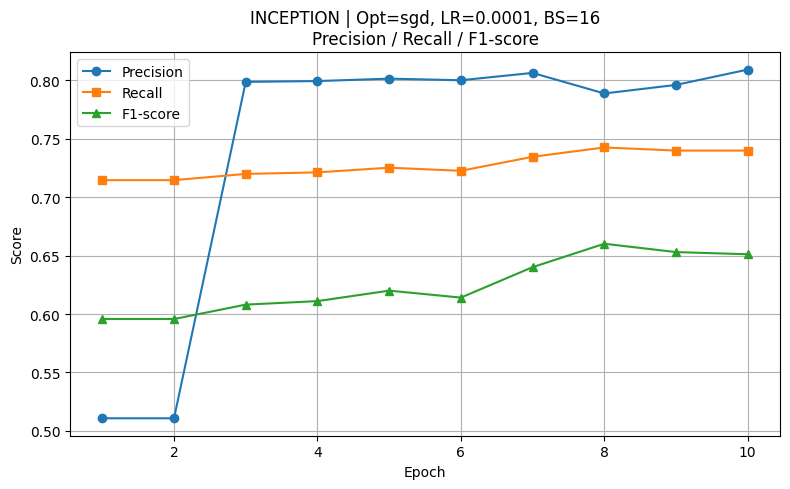


Eksperiment 8
Optimizer = sgd, LR = 0.0001, Batch Size = 32
Epoch 1/10 | Train Loss: 0.8867 | Val Loss: 0.6027 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
   ✅ Save: results/inception_sgd_lr0.0001_bs32_best.pth
Epoch 2/10 | Train Loss: 0.8280 | Val Loss: 0.5904 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
Epoch 3/10 | Train Loss: 0.8001 | Val Loss: 0.5824 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
Epoch 4/10 | Train Loss: 0.7781 | Val Loss: 0.5768 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
Epoch 5/10 | Train Loss: 0.7622 | Val Loss: 0.5720 | Precision: 0.5107 | Recall: 0.7147 | F1: 0.5957
Epoch 6/10 | Train Loss: 0.7504 | Val Loss: 0.5675 | Precision: 0.7968 | Recall: 0.7160 | F1: 0.5989
   ✅ Save: results/inception_sgd_lr0.0001_bs32_best.pth
Epoch 7/10 | Train Loss: 0.7377 | Val Loss: 0.5625 | Precision: 0.7995 | Recall: 0.7213 | F1: 0.6111
   ✅ Save: results/inception_sgd_lr0.0001_bs32_best.pth
Epoch 8/10 | Train Loss: 0.7289 | Val Loss: 0.5627 | Precision: 

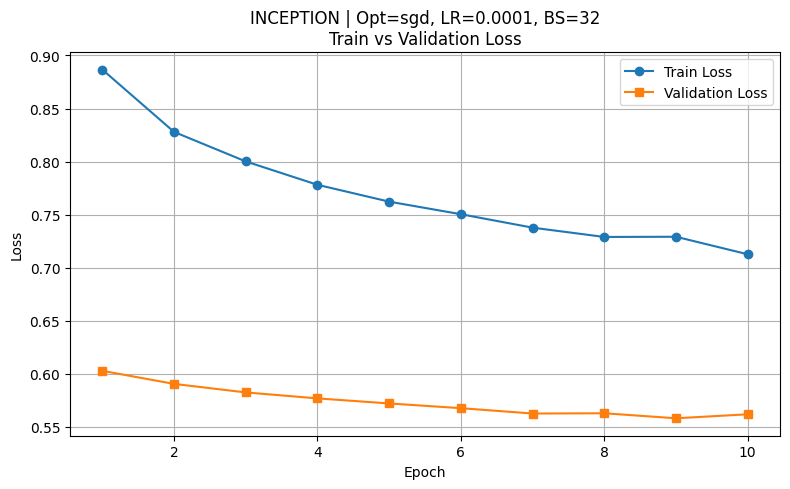

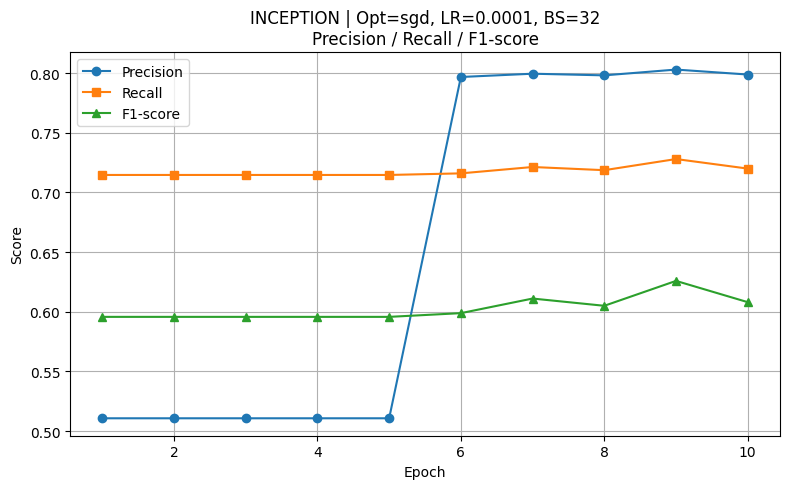


===== AutoML REZULTATI =====
  optimizer      lr  batch_size  best_val_loss   best_f1  \
4       sgd  0.0010          16       0.505143  0.751029   
0      adam  0.0010          16       0.504543  0.743081   
1      adam  0.0010          32       0.531785  0.740534   
5       sgd  0.0010          32       0.527481  0.715382   
2      adam  0.0001          16       0.541923  0.678885   
3      adam  0.0001          32       0.548478  0.660202   
6       sgd  0.0001          16       0.547304  0.660202   
7       sgd  0.0001          32       0.557991  0.625886   

                                      model_path  
4    results/inception_sgd_lr0.001_bs16_best.pth  
0   results/inception_adam_lr0.001_bs16_best.pth  
1   results/inception_adam_lr0.001_bs32_best.pth  
5    results/inception_sgd_lr0.001_bs32_best.pth  
2  results/inception_adam_lr0.0001_bs16_best.pth  
3  results/inception_adam_lr0.0001_bs32_best.pth  
6   results/inception_sgd_lr0.0001_bs16_best.pth  
7   results/inception

In [ ]:
model_name = 'inception'  # baseline, densenet, resnet, efficientnet, inception, vgg , convnext
epochs = 10
seed = 42

image_dir = "/content/drive/MyDrive/data/TN5000_forReview/JPEGImages"
annotation_dir = "/content/drive/MyDrive/data/TN5000_forReview/Annotations"

best_config, best_model_path, results_df = run_automl(
    model_name=model_name,
    image_dir=image_dir,
    annotation_dir=annotation_dir,
    device=device,
    epochs=epochs,
    seed=seed
)

print("\nNajbolja konfiguracija AutoML-a:")
print(best_config)
print("Putanja do najboljeg modela:", best_model_path)

# AutoML / Grid Search Rezultati - InceptionV3

## Opis eksperimenata

AutoML Grid Search je izveden za InceptionV3 model na datasetu TN5000.  
Model je inicijalizovan sa pretreniranim težinama (ImageNet), a zatim dodatno treniran na ciljanom skupu podataka.

Testirane su različite kombinacije hiperparametara:

- Optimizatori: Adam i SGD  
- Learning Rate: 0.001 i 0.0001  
- Batch Size: 16 i 32  

Ukupno je sprovedeno 7 eksperimenata, pri čemu je svaki trajao 10 epoha.

Cilj optimizacije bio je maksimizacija F1-score metrike, uz praćenje:
- Train Loss  
- Validation Loss  
- Precision  
- Recall  
- F1-score  

---

## Eksperimenti i detaljni rezultati

### Eksperiment 1: Adam, LR=0.001, BS=16

Model pokazuje relativno stabilno učenje, sa blagim oscilacijama tokom epoha.  
Najbolji rezultat postignut je u poslednjoj epohi.

Najbolji F1-score: **0.7431**

---

### Eksperiment 2: Adam, LR=0.001, BS=32

Povećanjem batch size-a dolazi do blagog pada performansi u odnosu na BS=16.  
Model je stabilan, ali manje precizan.

Najbolji F1-score: **0.7405**

---

### Eksperiment 3: Adam, LR=0.0001, BS=16

Niži learning rate značajno usporava proces učenja.  
Model postiže slabije rezultate i sporije konvergira.

Najbolji F1-score: **0.6789**

---

### Eksperiment 4: Adam, LR=0.0001, BS=32

Najslabije performanse među Adam konfiguracijama.  
Model ima problema sa konvergencijom i ne uspeva da dostigne visoke vrednosti F1-score-a.

Najbolji F1-score: **0.6602**

---

### Eksperiment 5: SGD, LR=0.001, BS=16

Ovaj eksperiment daje najbolje rezultate među svim testiranim konfiguracijama.  
Model pokazuje stabilan pad loss funkcije i kontinuirani rast performansi.

Najbolji F1-score: **0.7510** ✅

---

### Eksperiment 6: SGD, LR=0.001, BS=32

Model postiže solidne rezultate, ali slabije u odnosu na manji batch size.  
Performanse su stabilne, ali bez značajnog poboljšanja.

Najbolji F1-score: **0.7154**

---

### Eksperiment 7: SGD, LR=0.0001, BS=16

Kao i kod Adam optimizatora, nizak learning rate dovodi do sporog učenja.  
Model ne uspeva da dostigne performanse kao kod većeg learning rate-a.

Najbolji F1-score: **0.6602**

---

## Analiza rezultata

Na osnovu sprovedenih eksperimenata mogu se izvesti sledeći zaključci:

- **Optimizer:**
  - SGD se pokazao kao efikasniji u odnosu na Adam u ovom problemu  
  - Adam daje stabilnije, ali slabije rezultate  

- **Learning Rate:**
  - Veći learning rate (0.001) omogućava brže i efikasnije učenje  
  - Manji learning rate (0.0001) dovodi do sporije konvergencije i lošijih performansi  

- **Batch Size:**
  - Manji batch size (16) daje bolje rezultate  
  - Veći batch size (32) dovodi do blagog pada performansi  

---

## Zaključak

Najbolji rezultat postignut je u Eksperimentu 5 sa sledećim parametrima:

- Optimizer: SGD  
- Learning Rate: 0.001  
- Batch Size: 16  
- Precision: 0.7735
- Recall: 0.7800

Ova konfiguracija postiže **F1-score = 0.7510**, što predstavlja najbolji balans između preciznosti i odziva.

Iako InceptionV3 postiže solidne rezultate, u poređenju sa modernijim arhitekturama (npr. ConvNeXt), performanse su nešto slabije, što ukazuje na potencijal za dalje unapređenje modela kroz izbor naprednijih arhitektura ili dodatnu optimizaciju hiperparametara.

# Poređenje ConvNeXt Tiny i InceptionV3 na TN5000 datasetu

## ConvNeXt Tiny

Najbolja konfiguracija dobijena AutoML-om:

- **Optimizer:** Adam  
- **Learning Rate:** 5e-05  
- **Batch Size:** 16  
- **Precision:** 0.8844  
- **Recall:** 0.8893  
- **Najbolji F1-score:** 0.8888  

ConvNeXt Tiny je pokazao stabilnu konvergenciju tokom epoha, sa konstantnim poboljšanjem **precision** i **recall** metrika, što ukazuje na njegovu sposobnost da precizno i pouzdano klasifikuje noduse.

---

## InceptionV3

Najbolja konfiguracija dobijena AutoML-om:

- **Optimizer:** SGD  
- **Learning Rate:** 0.001  
- **Batch Size:** 16  
- **Precision:** 0.7735  
- **Recall:** 0.7800  
- **Najbolji F1-score:** 0.7510  

InceptionV3, iako inicijalizovan sa pretreniranim ImageNet težinama, pokazuje sporiju konvergenciju kod nižih learning rate-ova, a Adam optimizator daje stabilne, ali slabije rezultate u poređenju sa SGD. Veći batch size dovodi do blagog pada performansi.

---

## Poređenje i zaključak

- ConvNeXt Tiny nadmašuje InceptionV3 u svim ključnim metrikama (**F1-score, precision, recall**).  
- ConvNeXt Tiny koristi niži learning rate i manji batch size za optimalnu efikasnost, dok InceptionV3 postiže najbolje rezultate sa SGD i višim learning rate-om.  
- Modernija arhitektura ConvNeXt pokazuje bolju sposobnost učenja na TN5000 datasetu, sa stabilnijim performansama i boljim balansom između preciznosti i odziva, dok InceptionV3, iako solidan, zaostaje u odnosu na napredniju arhitekturu.